plotting com_traga for /data/big_rim/rsync_dcc_sum/Oct3V1/2025_04_10/20241212V1RE1L23Fmini_p20241212V1BE1L23F


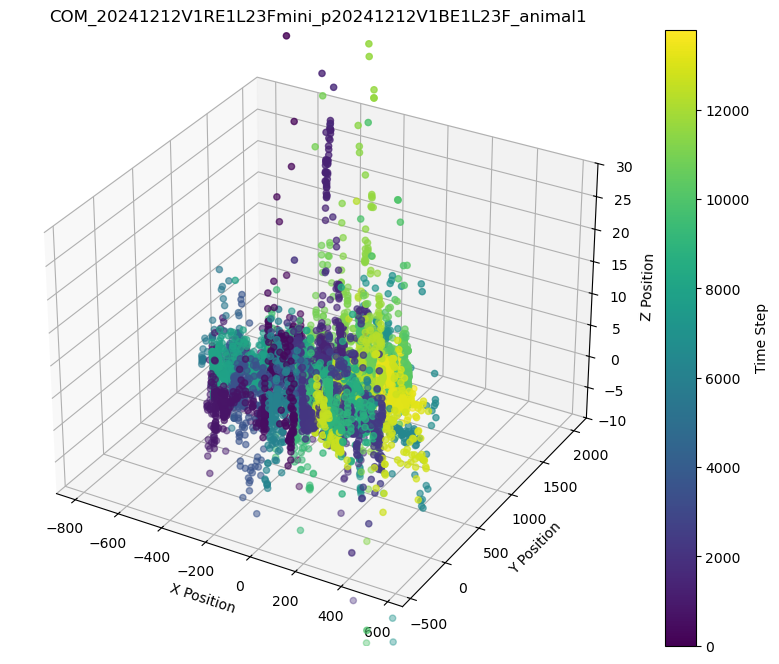

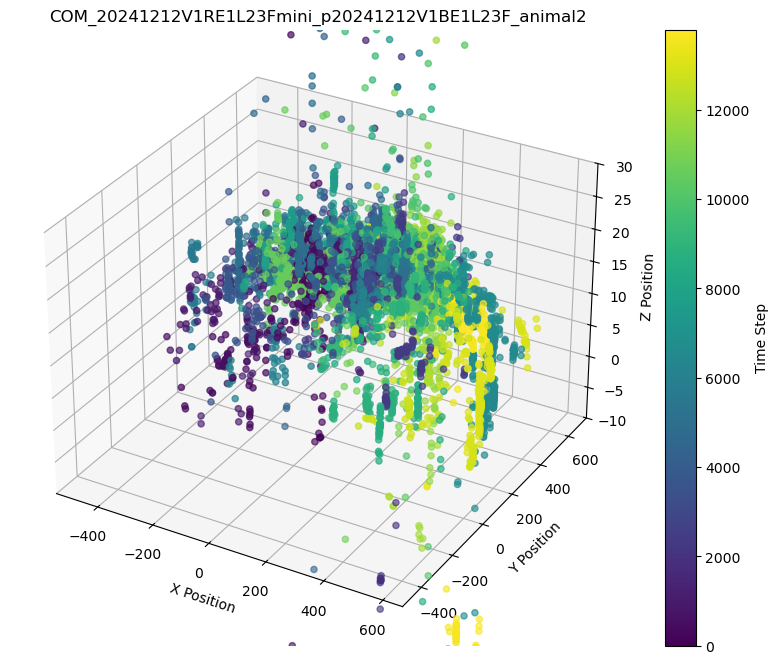

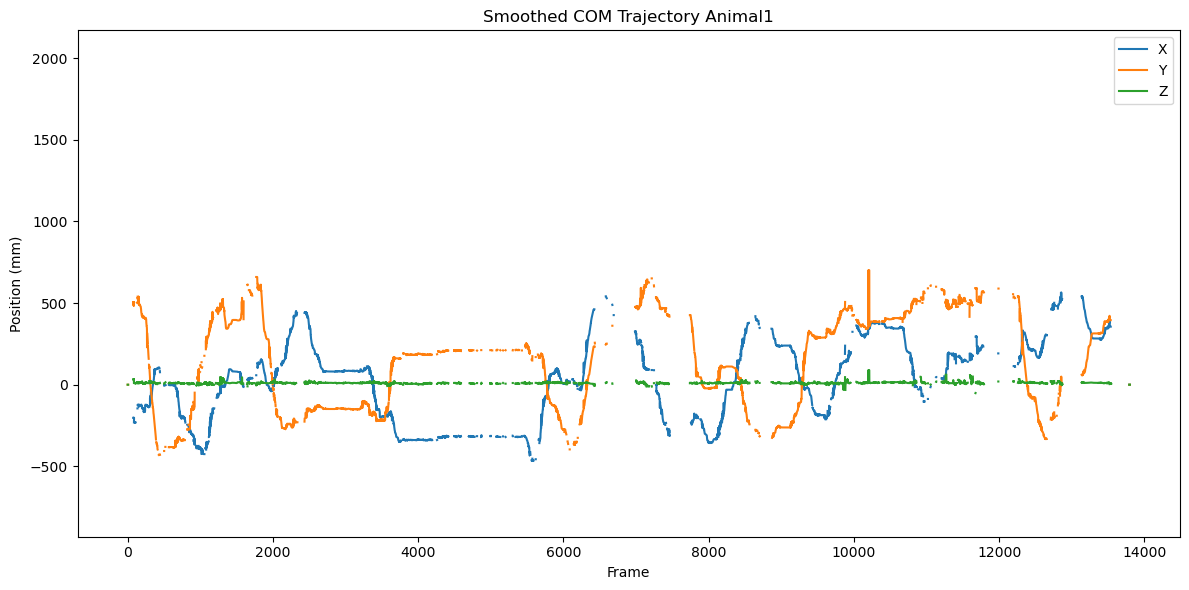

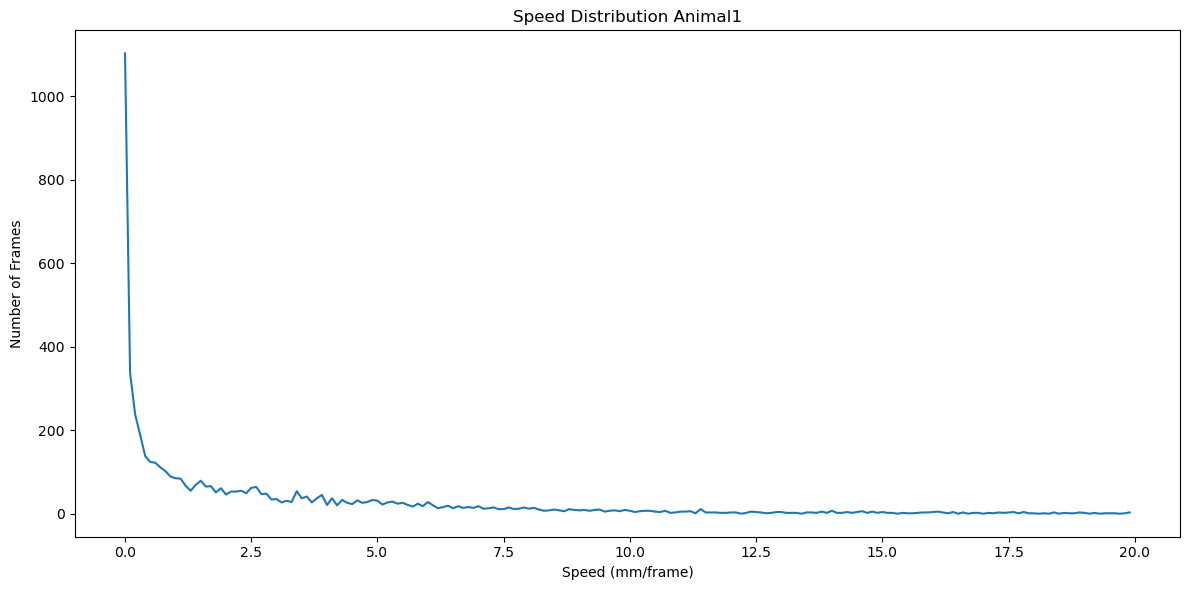

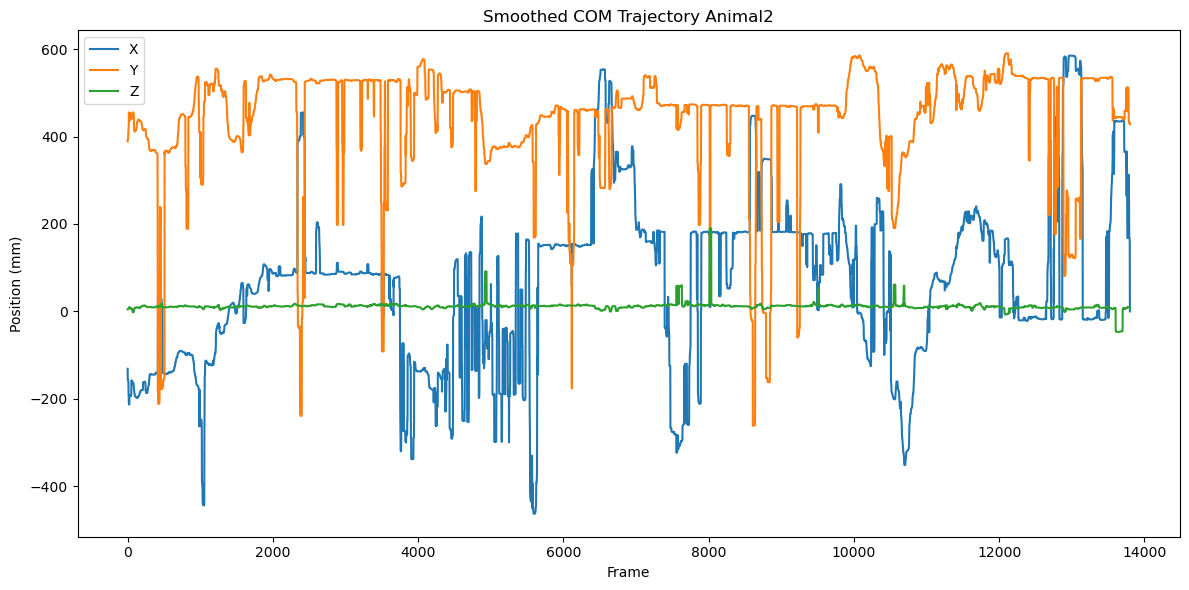

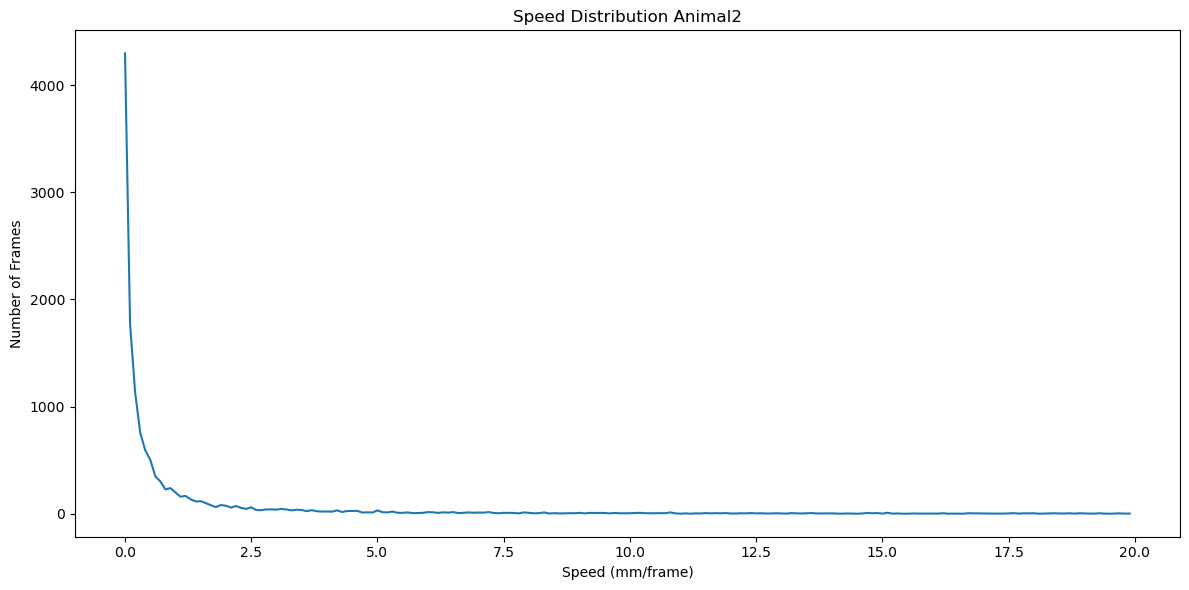

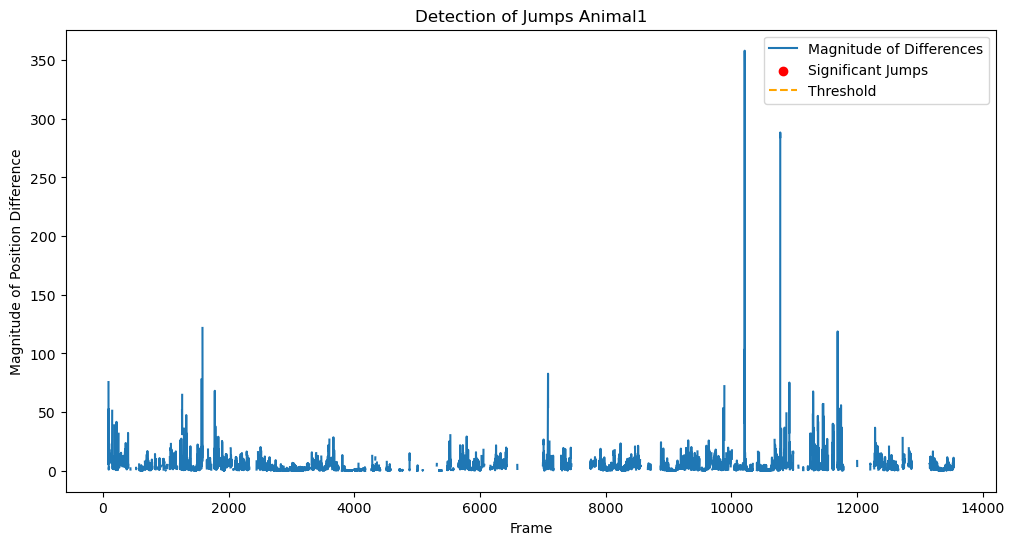

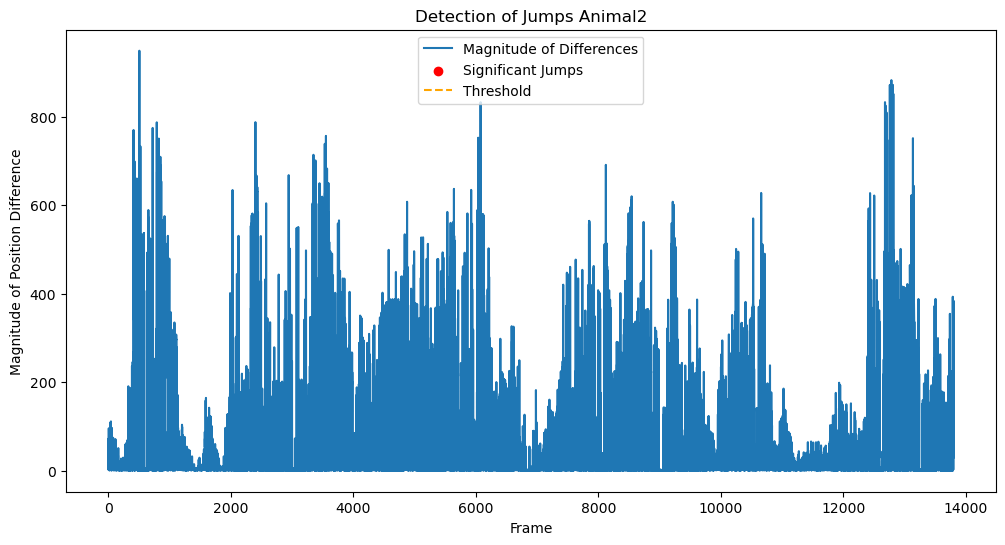

Frames with significant jumps per animal: {0: array([], dtype=int64), 1: array([], dtype=int64)}


In [ ]:
import sys
import os
sys.path.append(os.path.abspath('../..'))

# from utlis.vis_valid_utlis.com_trag_updated import plot_social_com_all
from utlis.vis_valid_utlis.scom_traga_utlis import plot_com_all_social

label1 = '/data/big_rim/rsync_dcc_sum/Oct3V1/Oct3V1/2024_12_18/20240919v1l5r1mini_p20240717PMC_social_test_11_30'
plot_com_all_social(label1,com_folder_name='yolo_tracking/predict_train_lone_social', perform_jump_indices=True) 



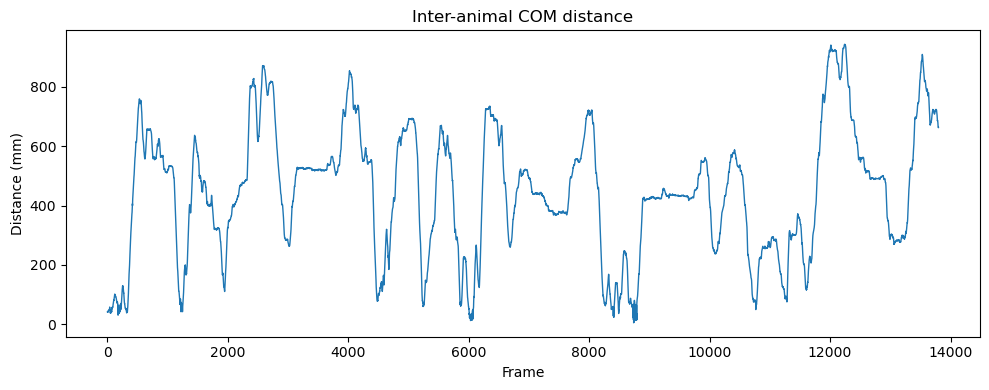

array([], dtype=int64)

In [11]:
# trying out a new evaluation fucntion for social
import sys
import os
sys.path.append(os.path.abspath('../..'))
from utlis.vis_valid_utlis.scom_traga_utlis import com_distance_qc

label1 = "/data/big_rim/rsync_dcc_sum/Oct3V1/2024_12_18/20240919v1l5r1mini_p20240717PMC_social_test_11_30"
# '/data/big_rim/rsync_dcc_sum/Oct3V1/2025_04_10/20241212V1RE1L23Fmini_p20241212V1BE1L23F'

# label1 = '/data/big_rim/rsync_dcc_sum/Oct3V1/2025_05_01/20250324PMCBmini_psamecageLE2_15_09'

# label1 = '/data/big_rim/rsync_dcc_sum/Oct3V1/2025_03_11/20241224PMCLE1mini_p20240303PMC2_14_44'
out = com_distance_qc(label1, com_folder_name='yolo_tracking/predict_train_lone_social_retrain_0917', jump_k=400, show_plot=True) #prefer_filtered=True,  jump_k=6,  first_n=3000,

out['jump_frames']

In [8]:
out['jump_frames'] # for '/data/big_rim/rsync_dcc_sum/Oct3V1/2025_04_10/20241212V1RE1L23Fmini_p20241212V1BE1L23F'

array([  941,   955,   956,   962,  1012,  1015,  1028,  1034,  1957,
        1973,  2009,  2012,  2013,  2048,  2051,  2052,  2073,  2075,
        2078,  2084,  2105,  2280,  2524,  2538,  2539,  2540,  2579,
        2581,  2584,  2602,  2621,  2626,  2627,  2638,  2642,  2644,
        2653,  2654,  2904,  2990,  3005,  3075,  3076,  3082,  3089,
        3091,  3093,  3100,  3101,  3119,  3138,  3141,  3178,  3214,
        3227,  3245,  3246,  3289,  3290,  3306,  3307,  3308,  3309,
        3311,  3312,  3348,  3354,  3499,  3533,  3534,  3814,  3957,
        4172,  4175,  5945,  5946,  6198,  6199,  6259,  6265,  6302,
        6303,  6307,  6325, 10201, 10243, 10246, 10532, 10533, 10681,
       10691, 10698, 10710, 12458, 12459, 12471, 12476, 12477, 12479,
       12486, 12487, 12496])

In [ ]:
failied_inc = "/data/big_rim/rsync_dcc_sum/Oct3V1/2025_04_10/20241212V1RE1L23Fmini_p20241212V1BE1L23F/yolo_tracking/predict_train_lone_social/vis/com_jump_indices_animal2.npy"

import numpy as np

# Load a .npy file
data = np.load(failied_inc)

print(type(data))     # Usually a numpy.ndarray
print(data.shape)     # Dimensions of the array
print(data)           # Print the contents


In [7]:


import os
import scipy.io as sio
import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial import ConvexHull
from scipy.optimize import least_squares


def plot_com_circle_for_path_social(
    base_path,
    pred_folder='DANNCE/predict00',
    com_dir='yolo_tracking/predict_train_lone_social_retrain_0917',
    vis_dir='COM/predict00/vis',
    filename=None
):
    """
    Load multi-animal COM (x,y,z), extract x/y for each animal,
    fit circles to each convex hull in x-y space,
    plot both COM trajectories in distinct colors,
    and save under base_path/vis/.

    Fallbacks:
      1) base_path/pred_folder/com3d_used.mat
      2) base_path/COM/predict00/com3d0.mat
    """
    # determine COM file
    primary = os.path.join(base_path, pred_folder, 'com3d_used.mat')
    fallback = os.path.join(base_path, com_dir, 'com3d0.mat')
    if os.path.isfile(primary):
        com_file = primary
    elif os.path.isfile(fallback):
        com_file = fallback
        print(f"Primary COM file not found; using fallback: {com_file}")
    else:
        raise FileNotFoundError(f"Neither {primary} nor {fallback} exists.")

    # load raw COM
    mat = sio.loadmat(com_file)
    raw = mat.get('com')
    if raw is None:
        raise KeyError(f"'com' variable not found in {com_file}")

    # reshape to (frames,2,n_animals)
    if raw.ndim == 3 and raw.shape[1] == 3:
        # already (frames,3,n); take x,y only
        com_xy = raw[:, :2, :]
    elif raw.ndim == 3 and raw.shape[1] == 2:
        # already (frames,2,n)
        com_xy = raw
    elif raw.ndim == 2 and raw.shape[1] % 3 == 0:
        # flattened (frames,3*n)
        n = raw.shape[1] // 3
        com3 = raw.reshape(-1, 3, n)
        com_xy = com3[:, :2, :]
    elif raw.ndim == 2 and raw.shape[1] % 2 == 0:
        # flattened (frames,2*n)
        n = raw.shape[1] // 2
        com_xy = raw.reshape(-1, 2, n)
    else:
        raise ValueError(
            f"Unexpected COM array shape {raw.shape},"
            " expected (frames,3,n) or (frames,3*n) or (frames,2,n) or (frames,2*n)"
        )

    frames, _, n_animals = com_xy.shape
    if n_animals < 2:
        raise ValueError(f"Expected at least 2 animals, found {n_animals}")

    # prepare plot
    fig, ax = plt.subplots(figsize=(8, 8))

    # color list for animals
    colors = ['C0', 'C1']

    def residuals(params, xh, yh):
        return np.hypot(xh - params[0], yh - params[1]) - params[2]

    # plot each animal's COM and circle fit
    for i in range(min(n_animals, 2)):
        x = com_xy[:, 0, i]
        y = com_xy[:, 1, i]
        # plot trajectory
        ax.scatter(x, y, color=colors[i], s=10, alpha=0.6, label=f'COM{i+1}')
        # convex hull and circle
        pts = np.stack([x, y], axis=1)
        hull = ConvexHull(pts)
        hx, hy = pts[hull.vertices, 0], pts[hull.vertices, 1]
        init = [hx.mean(), hy.mean(), np.mean(np.hypot(hx - hx.mean(), hy - hy.mean()))]
        res = least_squares(residuals, init, args=(hx, hy))
        xc, yc, r = res.x
        theta = np.linspace(0, 2*np.pi, 200)
        # ax.plot(xc + r*np.cos(theta), yc + r*np.sin(theta),
        #         linestyle='--', lw=2, color=colors[i],
        #         label=f'Fit{i+1}')
        # ax.scatter(xc, yc, s=50, marker='x', color=colors[i],
        #            label=f'Center{i+1}')

    ax.set_aspect('equal', 'box')
    ax.set_title(os.path.basename(base_path))
    ax.legend(loc='best', fontsize='small')

    # # save
    # save_folder = os.path.join(base_path, vis_dir)
    # os.makedirs(save_folder, exist_ok=True)
    # if filename is None:
    #     filename = 'com_circle.png'
    # save_path = os.path.join(save_folder, filename)
    # plt.tight_layout()
    # plt.savefig(save_path, dpi=300)
    # plt.close(fig)
    # print(f"Saved COM circle plot to: {save_path}")


Primary COM file not found; using fallback: /data/big_rim/rsync_dcc_sum/Oct3V1/2024_12_18/20240919v1l5r1mini_p20240717PMC_social_test_11_30/yolo_tracking/predict_train_lone_social_retrain_0917/com3d0.mat


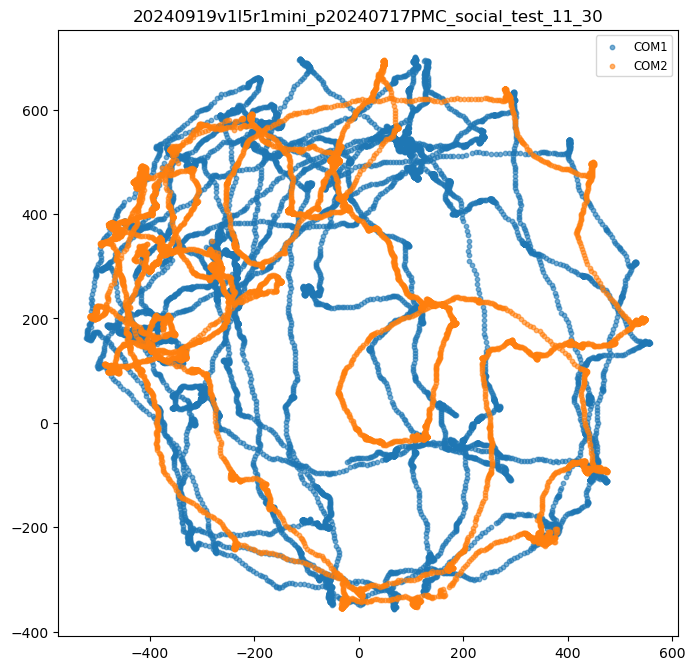

In [8]:
p = "/data/big_rim/rsync_dcc_sum/Oct3V1/2024_12_18/20240919v1l5r1mini_p20240717PMC_social_test_11_30"
plot_com_circle_for_path_social(p)

In [15]:
import os
import numpy as np
import scipy.io as sio
import matplotlib.pyplot as plt
from matplotlib.colors import to_rgb

def plot_com_social_with_time_and_meetings(
    base_path,
    pred_folder='DANNCE/predict00',
    com_dir='yolo_tracking/predict_train_lone_social_retrain_0917',
    vis_dir='COM/predict00/vis',
    filename_xy='com_xy_time.png',
    filename_t='distance_time.png',
    events_csv='meeting_events.csv',
    pair=(0, 1),
    fps=30.0,
    time=None,
    dist_thresh=120.0,
    min_event_frames=15,
    merge_gap_frames=10,
    # NEW: styling controls
    time_alpha_min=0.15,        # earliest frames transparency
    time_alpha_max=1.00,        # latest frames opacity
    animal_colors=('C0','C1'),  # fixed colors for the two animals
    event_cmap='tab10',         # colors for Meeting 1,2,…
    annotate_meetings=True,     # number meetings on both plots
    mark_meetings_on_xy=True,   # draw colored dots at meeting frames on XY
    show=True,
    save=True,
):
    """
    Fixed animal colors; time encoded via alpha (transparency).
    Meeting events (distance <= dist_thresh) are numbered and shown with the same color
    on both the XY plot and the distance–time plot.
    Returns dict(time, dist_xy, events, mask).
    """

    # ---------- 1) locate COM file ----------
    primary = os.path.join(base_path, pred_folder, 'com3d_used.mat')
    fallback = os.path.join(base_path, com_dir, 'com3d0.mat')
    com_file = primary if os.path.isfile(primary) else fallback
    if not os.path.isfile(com_file):
        raise FileNotFoundError(f"Neither {primary} nor {fallback} exists.")
    if com_file == fallback:
        print(f"Primary COM file not found; using fallback: {com_file}")

    # ---------- 2) load to (T,2,N) ----------
    raw = sio.loadmat(com_file).get('com')
    if raw is None:
        raise KeyError(f"'com' variable not found in {com_file}")

    if raw.ndim == 3 and raw.shape[1] == 3:      # (T,3,N) -> slice xy
        com_xy = raw[:, :2, :]
    elif raw.ndim == 3 and raw.shape[1] == 2:    # (T,2,N)
        com_xy = raw
    elif raw.ndim == 2 and raw.shape[1] % 3 == 0:  # (T,3N)
        N = raw.shape[1] // 3
        com_xy = raw.reshape(-1, 3, N)[:, :2, :]
    elif raw.ndim == 2 and raw.shape[1] % 2 == 0:  # (T,2N)
        N = raw.shape[1] // 2
        com_xy = raw.reshape(-1, 2, N)
    else:
        raise ValueError(f"Unexpected COM shape {raw.shape}")

    T, _, N = com_xy.shape
    if max(pair) >= N:
        raise ValueError(f"Pair index {pair} exceeds #animals {N}")

    # ---------- 3) time vector ----------
    if time is None:
        t = np.arange(T) / float(fps)
    else:
        t = np.asarray(time)
        if t.shape[0] != T:
            raise ValueError(f"time length {t.shape[0]} != frames {T}")

    # ---------- 4) pair coords + distance ----------
    x1, y1 = com_xy[:, 0, pair[0]], com_xy[:, 1, pair[0]]
    x2, y2 = com_xy[:, 0, pair[1]], com_xy[:, 1, pair[1]]
    valid = np.isfinite(x1) & np.isfinite(y1) & np.isfinite(x2) & np.isfinite(y2)

    dist_xy = np.full(T, np.nan)
    dist_xy[valid] = np.hypot(x1[valid] - x2[valid], y1[valid] - y2[valid])

    base_mask = (dist_xy <= dist_thresh)
    base_mask[~valid] = False

    # ---------- 5) segment utils (fixed, robust) ----------
    def _segments_from_mask(mask: np.ndarray) -> np.ndarray:
        m = np.asarray(mask, dtype=bool)
        if m.size == 0:
            return np.empty((0, 2), dtype=int)
        starts = np.flatnonzero(~np.concatenate(([False], m[:-1])) & m)      # 0->1
        ends   = np.flatnonzero(m & ~np.concatenate((m[1:], [False])))        # 1->0
        return np.column_stack((starts, ends)) if starts.size else np.empty((0, 2), int)

    def _filter_and_merge(segs: np.ndarray, min_len: int, gap: int) -> np.ndarray:
        if segs.size == 0:
            return segs
        lengths = segs[:, 1] - segs[:, 0] + 1
        segs = segs[lengths >= min_len]
        if segs.size == 0:
            return segs
        merged = [segs[0].tolist()]
        for s, e in segs[1:]:
            if s - merged[-1][1] - 1 <= gap:
                merged[-1][1] = e
            else:
                merged.append([s, e])
        return np.asarray(merged, dtype=int)

    segs = _filter_and_merge(_segments_from_mask(base_mask), min_event_frames, merge_gap_frames)

    # ---------- 6) event table ----------
    events = []
    for s, e in segs:
        w = slice(s, e + 1)
        finite = np.isfinite(dist_xy[w])
        if finite.any():
            rel = np.nanargmin(dist_xy[w])
            idx_rep = s + int(rel)           # representative frame at min distance
        else:
            idx_rep = (s + e) // 2
        events.append(dict(
            start_idx=int(s),
            end_idx=int(e),
            rep_idx=int(idx_rep),
            start_time=float(t[s]),
            end_time=float(t[e]),
            rep_time=float(t[idx_rep]),
            duration_s=float(t[e] - t[s]),
            min_distance=float(dist_xy[idx_rep]) if np.isfinite(dist_xy[idx_rep]) else np.nan,
        ))

    # ---------- 7) plotting ----------
    # (A) XY with fixed colors, time-as-alpha
    fig_xy, ax_xy = plt.subplots(figsize=(7, 7))

    # time -> alpha (normalized on valid frames only)
    if valid.any():
        tv = t[valid]
        if tv.size == 1:
            alphas = np.array([time_alpha_max])
        else:
            u = (tv - tv.min()) / (tv.max() - tv.min() + 1e-12)
            alphas = time_alpha_min + (time_alpha_max - time_alpha_min) * u
    else:
        alphas = np.array([])

    def _rgba_series(color_name, alpha_series):
        r, g, b = to_rgb(color_name)
        return np.column_stack([np.full(alpha_series.size, r),
                                np.full(alpha_series.size, g),
                                np.full(alpha_series.size, b),
                                alpha_series])

    rgba1 = _rgba_series(animal_colors[0], alphas) if alphas.size else np.empty((0,4))
    rgba2 = _rgba_series(animal_colors[1], alphas) if alphas.size else np.empty((0,4))

    if valid.any():
        v_idx = np.flatnonzero(valid)
        sc1 = ax_xy.scatter(x1[v_idx], y1[v_idx], c=rgba1, s=10, linewidths=0, label=f'COM{pair[0]+1}')
        sc2 = ax_xy.scatter(x2[v_idx], y2[v_idx], c=rgba2, s=10, linewidths=0, label=f'COM{pair[1]+1}')
        # mark first valid frame
        f0 = v_idx[0]
        ax_xy.plot([x1[f0]], [y1[f0]], marker='o', ms=6, mfc='none', mec='k')
        ax_xy.plot([x2[f0]], [y2[f0]], marker='o', ms=6, mfc='none', mec='k')

    # meeting markers + numbers on XY
    import matplotlib.cm as cm
    cmap_ev = cm.get_cmap(event_cmap, max(1, len(events)))
    if annotate_meetings and len(events) > 0:
        for k, ev in enumerate(events, start=1):
            idx = ev['rep_idx']
            col = cmap_ev(k-1)
            # dots on both animals at representative frame
            if 0 <= idx < T and valid[idx]:
                ax_xy.plot([x1[idx]], [y1[idx]], marker='o', ms=7, mfc=col, mec='k', mew=0.7)
                ax_xy.plot([x2[idx]], [y2[idx]], marker='o', ms=7, mfc=col, mec='k', mew=0.7)
                # number at midpoint
                mx = (x1[idx] + x2[idx]) * 0.5
                my = (y1[idx] + y2[idx]) * 0.5
                ax_xy.text(mx, my, str(k), color='k', fontsize=9,
                           ha='center', va='center',
                           bbox=dict(boxstyle="circle,pad=0.15", fc='white', ec=col, lw=0.9, alpha=0.85))
            # optional: also mark all frames within the event window
            if mark_meetings_on_xy:
                s, e = ev['start_idx'], ev['end_idx']
                mask_se = valid & (np.arange(T) >= s) & (np.arange(T) <= e)
                if mask_se.any():
                    ax_xy.scatter(x1[mask_se], y1[mask_se], s=10, facecolors=col, edgecolors='none', alpha=0.35)
                    ax_xy.scatter(x2[mask_se], y2[mask_se], s=10, facecolors=col, edgecolors='none', alpha=0.35)

    ax_xy.set_aspect('equal', 'box')
    ax_xy.set_title(os.path.basename(base_path))
    ax_xy.set_xlabel('x'); ax_xy.set_ylabel('y')
    ax_xy.legend(loc='best', fontsize='small')

    # (B) distance vs time + per-meeting color spans + numbers
    fig_t, ax_t = plt.subplots(figsize=(10, 3))
    ax_t.plot(t, dist_xy, lw=1.2, color='0.15')
    ax_t.axhline(dist_thresh, ls='--', lw=1, color='k', alpha=0.7)

    y_max = np.nanmax(dist_xy) if np.any(np.isfinite(dist_xy)) else dist_thresh
    y_text = 0.9 * y_max if np.isfinite(y_max) else dist_thresh

    for k, ev in enumerate(events, start=1):
        s, e = ev['start_idx'], ev['end_idx']
        col = cmap_ev(k-1)
        ax_t.axvspan(t[s], t[e], color=col, alpha=0.18)
        if annotate_meetings:
            tm = ev['rep_time']
            ax_t.text(tm, y_text, str(k), color='k', fontsize=9,
                      ha='center', va='center',
                      bbox=dict(boxstyle="circle,pad=0.15", fc='white', ec=col, lw=0.9, alpha=0.9))

    ax_t.set_xlabel('time (s)')
    ax_t.set_ylabel('distance (xy)')
    ax_t.set_title('Inter-animal distance (xy)')

    # ---------- 8) I/O ----------
    if save:
        out_dir = os.path.join(base_path, vis_dir)
        os.makedirs(out_dir, exist_ok=True)
        fig_xy.tight_layout(); fig_t.tight_layout()
        fig_xy.savefig(os.path.join(out_dir, filename_xy), dpi=300)
        fig_t.savefig(os.path.join(out_dir, filename_t), dpi=300)

        if events_csv:
            import csv
            with open(os.path.join(out_dir, events_csv), 'w', newline='') as f:
                w = csv.DictWriter(f, fieldnames=[
                    'start_idx','end_idx','rep_idx','start_time','end_time','rep_time','duration_s','min_distance'
                ])
                w.writeheader(); w.writerows(events)

    if not show:
        plt.close(fig_xy); plt.close(fig_t)

    return dict(time=t, dist_xy=dist_xy, events=events, mask=base_mask)


Primary COM file not found; using fallback: /data/big_rim/rsync_dcc_sum/Oct3V1/2024_12_18/20240919v1l5r1mini_p20240717PMC_social_test_11_30/yolo_tracking/predict_train_lone_social_retrain_0917/com3d0.mat


/tmp/ipykernel_184315/1071356205.py:171: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap_ev = cm.get_cmap(event_cmap, max(1, len(events)))


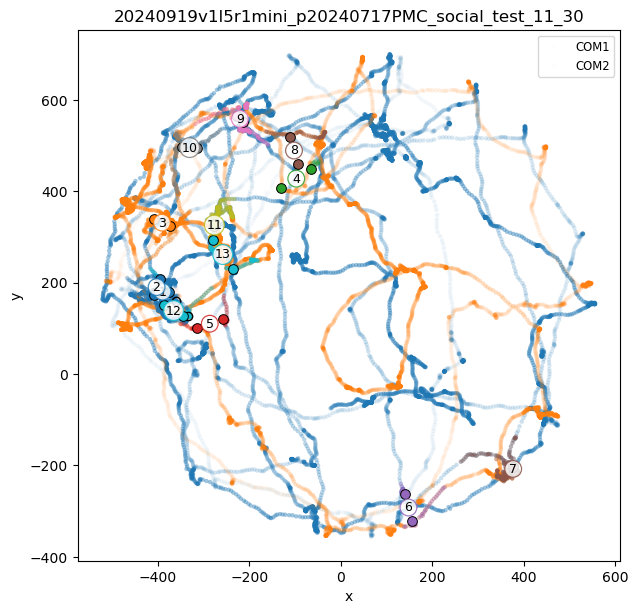

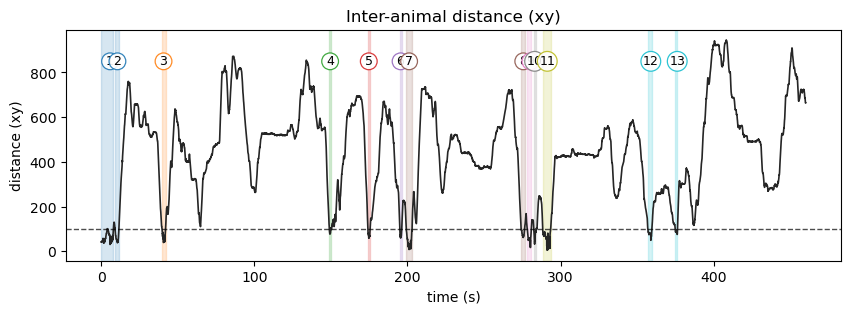

In [27]:
out = plot_com_social_with_time_and_meetings(
    base_path=p,
    dist_thresh=100.0,   # adjust manually
    time_alpha_min = 0.01,
    time_alpha_max = 0.5,
    # annotate_meetings=False,
    save=False,          # nothing savedexampl
    show=True            # still pops up the figures
)


In [42]:
import os
import numpy as np
import scipy.io as sio
import matplotlib.pyplot as plt
from matplotlib.collections import LineCollection
from matplotlib.lines import Line2D
import matplotlib.cm as cm

def plot_com_social_with_time_and_meetings(
    base_path,
    pred_folder='DANNCE/predict00',
    com_dir='yolo_tracking/predict_train_lone_social_retrain_0917',
    vis_dir='COM/predict00/vis',
    filename_xy='com_xy_events.png',
    filename_t='distance_time.png',
    events_csv='meeting_events.csv',
    pair=(0, 1),
    fps=30.0,
    time=None,
    dist_thresh=120.0,
    min_event_frames=15,
    merge_gap_frames=10,
    # XY style (event-focused)
    animal_colors=('C0','C1'),
    base_alpha=0.18,           # faint full-path alpha
    base_lw=1.0,               # faint full-path linewidth
    highlight_window_s=0.75,   # expand meeting window by ± seconds
    highlight_lw=2.2,          # linewidth for highlighted segments
    event_cmap='tab10',
    annotate_meetings=True,
    show=True,
    save=False,
):
    """
    Computes inter-animal XY distance and 'meeting' events (distance <= dist_thresh).
    XY panel: faint full paths per animal (fixed color), with thick colored segments
    around each meeting window (±highlight_window_s). Numbers tie to the distance plot.
    Returns dict(time, dist_xy, events, mask).
    """

    # ---------- 1) locate COM ----------
    primary = os.path.join(base_path, pred_folder, 'com3d_used.mat')
    fallback = os.path.join(base_path, com_dir, 'com3d0.mat')
    com_file = primary if os.path.isfile(primary) else fallback
    if not os.path.isfile(com_file):
        raise FileNotFoundError(f"Neither {primary} nor {fallback} exists.")
    if com_file == fallback:
        print(f"Primary COM file not found; using fallback: {com_file}")

    # ---------- 2) load to (T,2,N) ----------
    raw = sio.loadmat(com_file).get('com')
    if raw is None:
        raise KeyError(f"'com' variable not found in {com_file}")

    if raw.ndim == 3 and raw.shape[1] == 3:
        com_xy = raw[:, :2, :]
    elif raw.ndim == 3 and raw.shape[1] == 2:
        com_xy = raw
    elif raw.ndim == 2 and raw.shape[1] % 3 == 0:
        N = raw.shape[1] // 3
        com_xy = raw.reshape(-1, 3, N)[:, :2, :]
    elif raw.ndim == 2 and raw.shape[1] % 2 == 0:
        N = raw.shape[1] // 2
        com_xy = raw.reshape(-1, 2, N)
    else:
        raise ValueError(f"Unexpected COM shape {raw.shape}")

    T, _, N = com_xy.shape
    if max(pair) >= N:
        raise ValueError(f"Pair index {pair} exceeds #animals {N}")

    # ---------- 3) time ----------
    if time is None:
        t = np.arange(T) / float(fps)
    else:
        t = np.asarray(time)
        if t.shape[0] != T:
            raise ValueError(f"time length {t.shape[0]} != frames {T}")

    # ---------- 4) coords + distance ----------
    x1, y1 = com_xy[:, 0, pair[0]], com_xy[:, 1, pair[0]]
    x2, y2 = com_xy[:, 0, pair[1]], com_xy[:, 1, pair[1]]
    valid = np.isfinite(x1) & np.isfinite(y1) & np.isfinite(x2) & np.isfinite(y2)

    dist_xy = np.full(T, np.nan)
    dist_xy[valid] = np.hypot(x1[valid] - x2[valid], y1[valid] - y2[valid])

    base_mask = (dist_xy <= dist_thresh)
    base_mask[~valid] = False

    # ---------- 5) segments (robust) ----------
    def _segments_from_mask(mask: np.ndarray) -> np.ndarray:
        m = np.asarray(mask, dtype=bool)
        if m.size == 0:
            return np.empty((0, 2), dtype=int)
        starts = np.flatnonzero(~np.concatenate(([False], m[:-1])) & m)
        ends   = np.flatnonzero(m & ~np.concatenate((m[1:], [False])))
        return np.column_stack((starts, ends)) if starts.size else np.empty((0, 2), int)

    def _filter_and_merge(segs: np.ndarray, min_len: int, gap: int) -> np.ndarray:
        if segs.size == 0:
            return segs
        lengths = segs[:, 1] - segs[:, 0] + 1
        segs = segs[lengths >= min_len]
        if segs.size == 0:
            return segs
        merged = [segs[0].tolist()]
        for s, e in segs[1:]:
            if s - merged[-1][1] - 1 <= gap:
                merged[-1][1] = e
            else:
                merged.append([s, e])
        return np.asarray(merged, dtype=int)

    segs = _filter_and_merge(_segments_from_mask(base_mask), min_event_frames, merge_gap_frames)

    # ---------- 6) event table ----------
    events = []
    for s, e in segs:
        w = slice(s, e + 1)
        finite = np.isfinite(dist_xy[w])
        idx_rep = (s + e) // 2
        if finite.any():
            idx_rep = s + int(np.nanargmin(dist_xy[w]))
        events.append(dict(
            start_idx=int(s),
            end_idx=int(e),
            rep_idx=int(idx_rep),
            start_time=float(t[s]),
            end_time=float(t[e]),
            rep_time=float(t[idx_rep]),
            duration_s=float(t[e] - t[s]),
            min_distance=float(dist_xy[idx_rep]) if np.isfinite(dist_xy[idx_rep]) else np.nan,
        ))

    # ---------- helpers for XY line drawing ----------
    def _line_segments(x, y, mask_pairs):
        # segments between (i,i+1) where both frames valid
        pts = np.column_stack([x, y])
        segs = np.stack([pts[:-1], pts[1:]], axis=1)
        return segs[mask_pairs]

    valid_seg = valid[:-1] & valid[1:]
    cmap_ev = cm.get_cmap(event_cmap, max(1, len(events)))
    pad = int(round(highlight_window_s * fps))

    # ---------- 7A) XY: faint full path + colored meeting highlights ----------
    fig_xy, ax_xy = plt.subplots(figsize=(7, 7))

    # faint base (full trajectory)
    if valid_seg.any():
        segs1_all = _line_segments(x1, y1, valid_seg)
        segs2_all = _line_segments(x2, y2, valid_seg)
        ax_xy.add_collection(LineCollection(segs1_all, colors=animal_colors[0], linewidths=base_lw, alpha=base_alpha))
        ax_xy.add_collection(LineCollection(segs2_all, colors=animal_colors[1], linewidths=base_lw, alpha=base_alpha))

    # highlight windows around each meeting
    for k, ev in enumerate(events, start=1):
        col = cmap_ev(k-1)
        s = max(0, ev['start_idx'] - pad)
        e = min(T-1, ev['end_idx'] + pad)
        win_seg = np.zeros_like(valid_seg)
        win_seg[s:e] = True
        mask1 = valid_seg & win_seg
        if mask1.any():
            ax_xy.add_collection(LineCollection(_line_segments(x1, y1, mask1),
                                                colors=col, linewidths=highlight_lw, alpha=0.95))
            ax_xy.add_collection(LineCollection(_line_segments(x2, y2, mask1),
                                                colors=col, linewidths=highlight_lw, alpha=0.95))
        
        # numbered midpoint (respect annotate_meetings)
        if annotate_meetings:
            idx = ev['rep_idx']
            if 0 <= idx < T and valid[idx]:
                mx, my = (x1[idx] + x2[idx]) * 0.5, (y1[idx] + y2[idx]) * 0.5
                ax_xy.text(mx, my, str(k), color='k', fontsize=9, ha='center', va='center',
                        bbox=dict(boxstyle="circle,pad=0.15", fc='white', ec=col, lw=0.9, alpha=0.95))
        
        # numbered midpoint
        # idx = ev['rep_idx']
        # if 0 <= idx < T and valid[idx]:
        #     mx, my = (x1[idx] + x2[idx]) * 0.5, (y1[idx] + y2[idx]) * 0.5
        #     ax_xy.text(mx, my, str(k), color='k', fontsize=9, ha='center', va='center',
        #                bbox=dict(boxstyle="circle,pad=0.15", fc='white', ec=col, lw=0.9, alpha=0.95))

    # mark first valid frame per animal
    if valid.any():
        f0 = np.flatnonzero(valid)[0]
        ax_xy.plot([x1[f0]], [y1[f0]], marker='o', ms=4, mfc='C0', mec='none')
        ax_xy.plot([x2[f0]], [y2[f0]], marker='o', ms=4, mfc='C1', mec='none')
        # bewlow i slike start with black circle??
        # ax_xy.plot([x1[f0]], [y1[f0]], marker='o', ms=6, mfc='none', mec='k')
        # ax_xy.plot([x2[f0]], [y2[f0]], marker='o', ms=6, mfc='none', mec='k')

    ax_xy.set_aspect('equal', 'box')
    ax_xy.set_title(os.path.basename(base_path))
    ax_xy.set_xlabel('x'); ax_xy.set_ylabel('y')
    # legend proxies
    proxy1 = Line2D([0],[0], color=animal_colors[0], lw=2)
    proxy2 = Line2D([0],[0], color=animal_colors[1], lw=2)
    ax_xy.legend([proxy1, proxy2], [f'COM{pair[0]+1}', f'COM{pair[1]+1}'], fontsize='small', loc='best')

    # ---------- 7B) distance–time with colored spans ----------
    fig_t, ax_t = plt.subplots(figsize=(10, 3))
    ax_t.plot(t, dist_xy, lw=1.2, color='0.15')
    ax_t.axhline(dist_thresh, ls='--', lw=1, color='k', alpha=0.7)

    y_max = np.nanmax(dist_xy) if np.any(np.isfinite(dist_xy)) else dist_thresh
    y_text = 0.9 * y_max if np.isfinite(y_max) else dist_thresh
    for k, ev in enumerate(events, start=1):
        s, e = ev['start_idx'], ev['end_idx']
        col = cmap_ev(k-1)
        ax_t.axvspan(t[s], t[e], color=col, alpha=0.18)
        if annotate_meetings:
            ax_t.text(ev['rep_time'], y_text, str(k), color='k', fontsize=9,
                      ha='center', va='center',
                      bbox=dict(boxstyle="circle,pad=0.15", fc='white', ec=col, lw=0.9, alpha=0.9))

    ax_t.set_xlabel('time (s)')
    ax_t.set_ylabel('distance (xy)')
    ax_t.set_title('Inter-animal distance (xy)')

    # ---------- 8) I/O ----------
    if save:
        out_dir = os.path.join(base_path, vis_dir)
        os.makedirs(out_dir, exist_ok=True)
        fig_xy.tight_layout(); fig_t.tight_layout()
        fig_xy.savefig(os.path.join(out_dir, filename_xy), dpi=300)
        fig_t.savefig(os.path.join(out_dir, filename_t), dpi=300)
        if events_csv:
            import csv
            with open(os.path.join(out_dir, events_csv), 'w', newline='') as f:
                w = csv.DictWriter(f, fieldnames=[
                    'start_idx','end_idx','rep_idx','start_time','end_time','rep_time','duration_s','min_distance'
                ])
                w.writeheader(); w.writerows(events)

    if not show:
        plt.close(fig_xy); plt.close(fig_t)

    return dict(time=t, dist_xy=dist_xy, events=events, mask=base_mask)


Primary COM file not found; using fallback: /data/big_rim/rsync_dcc_sum/Oct3V1/2024_12_18/20240919v1l5r1mini_p20240717PMC_social_test_11_30/yolo_tracking/predict_train_lone_social_retrain_0917/com3d0.mat


/tmp/ipykernel_184315/2167175827.py:144: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap_ev = cm.get_cmap(event_cmap, max(1, len(events)))


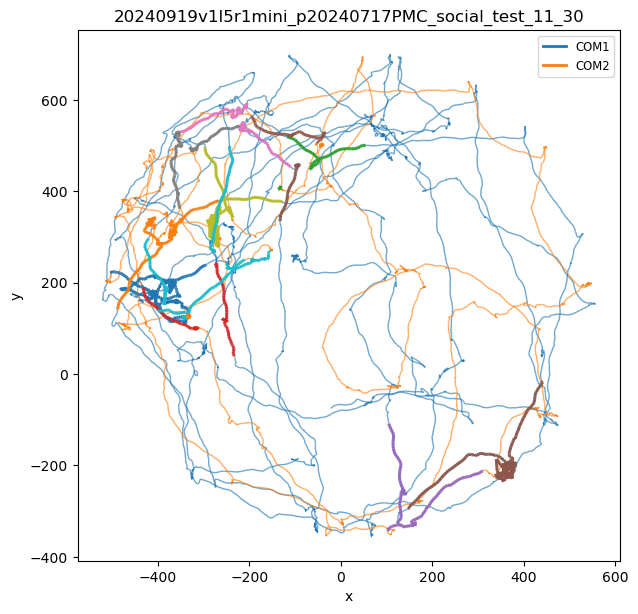

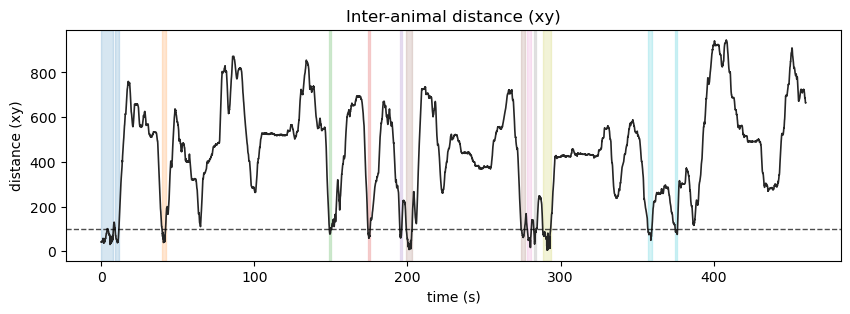

In [48]:
out = plot_com_social_with_time_and_meetings(
    base_path=p,
    dist_thresh=100,#100.0,   # adjust manually
    # time_alpha_min = 0.01,
    # time_alpha_max = 0.5,
    annotate_meetings=False,
    base_alpha = 0.65,
    save=False,          # nothing savedexampl
    show=True            # still pops up the figures
)


In [51]:
import os
import numpy as np
import scipy.io as sio
import matplotlib.pyplot as plt
from matplotlib.collections import LineCollection
from matplotlib.lines import Line2D
import matplotlib.cm as cm

def plot_com_social_with_time_and_meetings(
    base_path,
    pred_folder='DANNCE/predict00',
    com_dir='yolo_tracking/predict_train_lone_social_retrain_0917',
    vis_dir='COM/predict00/vis',
    filename_xy='com_xy_events.png',
    filename_t='distance_time.png',
    events_csv='meeting_events.csv',
    pair=(0, 1),
    fps=30.0,
    time=None,
    dist_thresh=120.0,          # meeting threshold (mm)
    min_event_frames=15,
    merge_gap_frames=10,
    # XY style (event-focused)
    animal_colors=('C0','C1'),
    base_alpha=0.18,            # faint full-path alpha
    base_lw=1.0,                # faint full-path linewidth
    highlight_window_s=0.75,    # expand meeting window by ± seconds
    highlight_lw=2.2,           # overlay (animal) linewidth
    outline_extra=1.6,          # underlay (meeting color) extra width
    # Event coloring: set `event_color` to a single color (e.g. 'tab:purple') to override the cmap
    event_color=None,           # None → use colormap; otherwise string/RGBA applied to all events
    event_cmap='viridis',       # colorblind-friendly
    event_cmap_range=(0.15, 0.85),  # avoid very dark/very light ends of cmap
    annotate_meetings=True,
    show=True,
    save=False,
):
    """
    Computes inter-animal XY distance and 'meeting' events (distance <= dist_thresh).

    XY panel:
      - faint full paths per animal (fixed colors),
      - for each meeting window, dual-stroke highlight:
          underlay = meeting color (thicker), overlay = animal color (thinner).
      - optional numbered badges at the midpoint (annotate_meetings).

    Distance panel:
      - distance (mm) line + threshold,
      - colored spans for meetings (same colors as XY highlights),
      - optional numbered badges.

    Returns dict(time, dist_xy, events, mask).
    """

    # ---------- 1) locate COM ----------
    primary = os.path.join(base_path, pred_folder, 'com3d_used.mat')
    fallback = os.path.join(base_path, com_dir, 'com3d0.mat')
    com_file = primary if os.path.isfile(primary) else fallback
    if not os.path.isfile(com_file):
        raise FileNotFoundError(f"Neither {primary} nor {fallback} exists.")
    if com_file == fallback:
        print(f"Primary COM file not found; using fallback: {com_file}")

    # ---------- 2) load to (T,2,N) ----------
    raw = sio.loadmat(com_file).get('com')
    if raw is None:
        raise KeyError(f"'com' variable not found in {com_file}")

    if raw.ndim == 3 and raw.shape[1] == 3:
        com_xy = raw[:, :2, :]
    elif raw.ndim == 3 and raw.shape[1] == 2:
        com_xy = raw
    elif raw.ndim == 2 and raw.shape[1] % 3 == 0:
        N = raw.shape[1] // 3
        com_xy = raw.reshape(-1, 3, N)[:, :2, :]
    elif raw.ndim == 2 and raw.shape[1] % 2 == 0:
        N = raw.shape[1] // 2
        com_xy = raw.reshape(-1, 2, N)
    else:
        raise ValueError(f"Unexpected COM shape {raw.shape}")

    T, _, N = com_xy.shape
    if max(pair) >= N:
        raise ValueError(f"Pair index {pair} exceeds #animals {N}")

    # ---------- 3) time ----------
    if time is None:
        t = np.arange(T) / float(fps)
    else:
        t = np.asarray(time)
        if t.shape[0] != T:
            raise ValueError(f"time length {t.shape[0]} != frames {T}")

    # ---------- 4) coords + distance (mm) ----------
    x1, y1 = com_xy[:, 0, pair[0]], com_xy[:, 1, pair[0]]
    x2, y2 = com_xy[:, 0, pair[1]], com_xy[:, 1, pair[1]]
    valid = np.isfinite(x1) & np.isfinite(y1) & np.isfinite(x2) & np.isfinite(y2)

    dist_xy = np.full(T, np.nan)
    dist_xy[valid] = np.hypot(x1[valid] - x2[valid], y1[valid] - y2[valid])  # mm

    base_mask = (dist_xy <= dist_thresh)
    base_mask[~valid] = False

    # ---------- 5) segments (robust) ----------
    def _segments_from_mask(mask: np.ndarray) -> np.ndarray:
        m = np.asarray(mask, dtype=bool)
        if m.size == 0:
            return np.empty((0, 2), dtype=int)
        starts = np.flatnonzero(~np.concatenate(([False], m[:-1])) & m)
        ends   = np.flatnonzero(m & ~np.concatenate((m[1:], [False])))
        return np.column_stack((starts, ends)) if starts.size else np.empty((0, 2), int)

    def _filter_and_merge(segs: np.ndarray, min_len: int, gap: int) -> np.ndarray:
        if segs.size == 0:
            return segs
        lengths = segs[:, 1] - segs[:, 0] + 1
        segs = segs[lengths >= min_len]
        if segs.size == 0:
            return segs
        merged = [segs[0].tolist()]
        for s, e in segs[1:]:
            if s - merged[-1][1] - 1 <= gap:
                merged[-1][1] = e
            else:
                merged.append([s, e])
        return np.asarray(merged, dtype=int)

    segs = _filter_and_merge(_segments_from_mask(base_mask), min_event_frames, merge_gap_frames)

    # ---------- 6) event table ----------
    events = []
    for s, e in segs:
        w = slice(s, e + 1)
        finite = np.isfinite(dist_xy[w])
        idx_rep = (s + e) // 2
        if finite.any():
            idx_rep = s + int(np.nanargmin(dist_xy[w]))
        events.append(dict(
            start_idx=int(s),
            end_idx=int(e),
            rep_idx=int(idx_rep),
            start_time=float(t[s]),
            end_time=float(t[e]),
            rep_time=float(t[idx_rep]),
            duration_s=float(t[e] - t[s]),
            min_distance=float(dist_xy[idx_rep]) if np.isfinite(dist_xy[idx_rep]) else np.nan,
        ))

    # ---------- helpers for XY line drawing ----------
    def _line_segments(x, y, mask_pairs):
        # segments between (i,i+1) where both frames valid
        pts = np.column_stack([x, y])
        segs = np.stack([pts[:-1], pts[1:]], axis=1)
        return segs[mask_pairs]

    valid_seg = valid[:-1] & valid[1:]

    # color picker shared by BOTH plots
    if event_color is None:
        cmap = cm.get_cmap(event_cmap)
        lo, hi = event_cmap_range
        # clamp and handle empty
        lo, hi = float(np.clip(lo, 0, 1)), float(np.clip(hi, 0, 1))
        if len(events) <= 1:
            ev_cols = [cmap((lo + hi) / 2.0)]
        else:
            ev_cols = [cmap(v) for v in np.linspace(lo, hi, len(events))]
    else:
        ev_cols = [event_color] * max(1, len(events))

    pad = int(round(highlight_window_s * fps))

    # ---------- 7A) XY: faint full path + dual-stroke meeting highlights ----------
    fig_xy, ax_xy = plt.subplots(figsize=(7, 7))

    # faint base (full trajectory)
    if valid_seg.any():
        segs1_all = _line_segments(x1, y1, valid_seg)
        segs2_all = _line_segments(x2, y2, valid_seg)
        ax_xy.add_collection(LineCollection(segs1_all, colors=animal_colors[0], linewidths=base_lw, alpha=base_alpha))
        ax_xy.add_collection(LineCollection(segs2_all, colors=animal_colors[1], linewidths=base_lw, alpha=base_alpha))

    # dual-stroke highlight per meeting (colors synced to distance plot)
    for k, ev in enumerate(events, start=1):
        col = ev_cols[k-1]
        s_frame = max(0, ev['start_idx'] - pad)
        e_frame = min(T-1, ev['end_idx'] + pad)
        seg_lo = max(0, s_frame)
        seg_hi = min(T-2, e_frame - 1)  # inclusive segment index
        if seg_lo <= seg_hi:
            win_seg = np.zeros_like(valid_seg, dtype=bool)
            win_seg[seg_lo:seg_hi+1] = True
            mask1 = valid_seg & win_seg
        else:
            mask1 = np.zeros_like(valid_seg, dtype=bool)

        if mask1.any():
            # Underlay: meeting color (thicker)
            ax_xy.add_collection(LineCollection(_line_segments(x1, y1, mask1),
                                                colors=col, linewidths=highlight_lw + outline_extra, alpha=0.95))
            ax_xy.add_collection(LineCollection(_line_segments(x2, y2, mask1),
                                                colors=col, linewidths=highlight_lw + outline_extra, alpha=0.95))
            # Overlay: animal identity color (thinner)
            ax_xy.add_collection(LineCollection(_line_segments(x1, y1, mask1),
                                                colors=animal_colors[0], linewidths=highlight_lw, alpha=1.0))
            ax_xy.add_collection(LineCollection(_line_segments(x2, y2, mask1),
                                                colors=animal_colors[1], linewidths=highlight_lw, alpha=1.0))

        # optional number at midpoint
        if annotate_meetings:
            idx = ev['rep_idx']
            if 0 <= idx < T and valid[idx]:
                mx, my = (x1[idx] + x2[idx]) * 0.5, (y1[idx] + y2[idx]) * 0.5
                ax_xy.text(mx, my, str(k), color='k', fontsize=9, ha='center', va='center',
                           bbox=dict(boxstyle="circle,pad=0.15", fc='white', ec=col, lw=0.9, alpha=0.95))

    # mark first valid frame per animal (filled with identity color)
    if valid.any():
        f0 = np.flatnonzero(valid)[0]
        ax_xy.plot([x1[f0]], [y1[f0]], marker='o', ms=4, mfc=animal_colors[0], mec='none')
        ax_xy.plot([x2[f0]], [y2[f0]], marker='o', ms=4, mfc=animal_colors[1], mec='none')

    ax_xy.set_aspect('equal', 'box')
    ax_xy.set_title(os.path.basename(base_path))
    ax_xy.set_xlabel('x (mm)')   # units
    ax_xy.set_ylabel('y (mm)')   # units

    # simple animal legend only
    animal_legend = [Line2D([0],[0], color=animal_colors[0], lw=2),
                     Line2D([0],[0], color=animal_colors[1], lw=2)]
    ax_xy.legend(animal_legend, [f'COM{pair[0]+1}', f'COM{pair[1]+1}'],
                 fontsize='small', loc='upper left')

    # ---------- 7B) distance–time with colored spans (same colors) ----------
    fig_t, ax_t = plt.subplots(figsize=(10, 3))
    ax_t.plot(t, dist_xy, lw=1.2, color='0.15')
    ax_t.axhline(dist_thresh, ls='--', lw=1, color='k', alpha=0.7)

    y_max = np.nanmax(dist_xy) if np.any(np.isfinite(dist_xy)) else dist_thresh
    y_text = 0.9 * y_max if np.isfinite(y_max) else dist_thresh
    for k, ev in enumerate(events, start=1):
        s, e = ev['start_idx'], ev['end_idx']
        col = ev_cols[k-1]
        ax_t.axvspan(t[s], t[e], color=col, alpha=0.18)
        if annotate_meetings:
            ax_t.text(ev['rep_time'], y_text, str(k), color='k', fontsize=9,
                      ha='center', va='center',
                      bbox=dict(boxstyle="circle,pad=0.15", fc='white', ec=col, lw=0.9, alpha=0.9))

    ax_t.set_xlabel('time (s)')
    ax_t.set_ylabel('distance (mm)')   # units
    ax_t.set_title('Inter-animal COM distance (xy)')

    # ---------- 8) I/O ----------
    if save:
        out_dir = os.path.join(base_path, vis_dir)
        os.makedirs(out_dir, exist_ok=True)
        fig_xy.tight_layout(); fig_t.tight_layout()
        fig_xy.savefig(os.path.join(out_dir, filename_xy), dpi=300)
        fig_t.savefig(os.path.join(out_dir, filename_t), dpi=300)
        if events_csv:
            import csv
            with open(os.path.join(out_dir, events_csv), 'w', newline=True) as f:
                w = csv.DictWriter(f, fieldnames=[
                    'start_idx','end_idx','rep_idx','start_time','end_time','rep_time','duration_s','min_distance'
                ])
                w.writeheader(); w.writerows(events)

    if not show:
        plt.close(fig_xy); plt.close(fig_t)

    return dict(time=t, dist_xy=dist_xy, events=events, mask=base_mask)


Primary COM file not found; using fallback: /data/big_rim/rsync_dcc_sum/Oct3V1/2024_12_18/20240919v1l5r1mini_p20240717PMC_social_test_11_30/yolo_tracking/predict_train_lone_social_retrain_0917/com3d0.mat


/tmp/ipykernel_184315/1759878422.py:161: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap(event_cmap)


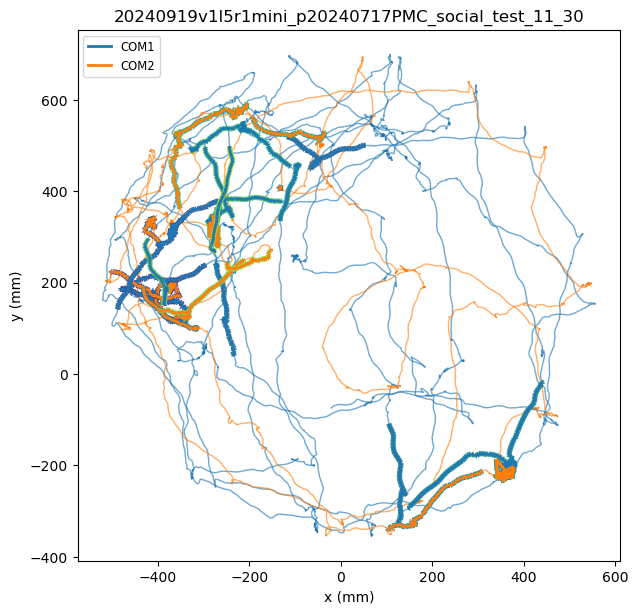

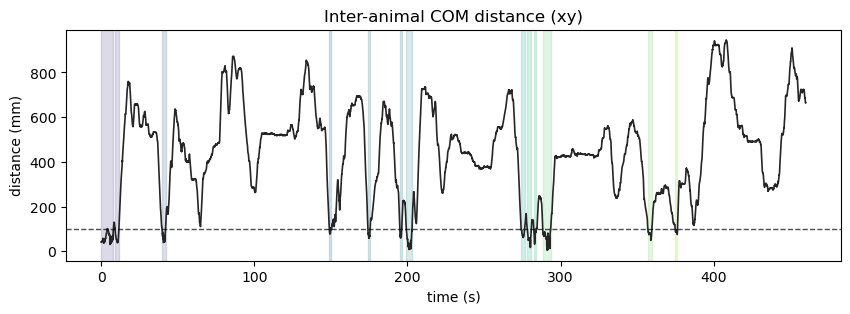

In [52]:
out = plot_com_social_with_time_and_meetings(
    base_path=p,
    dist_thresh=100,#100.0,   # adjust manually
    # time_alpha_min = 0.01,
    # time_alpha_max = 0.5,
    annotate_meetings=False,
    base_alpha = 0.65,
    save=False,          # nothing savedexampl
    show=True            # still pops up the figures
)


In [53]:
import os
import numpy as np
import scipy.io as sio
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from matplotlib import cm

def plot_com_occupancy_heatmaps(
    base_path,
    pred_folder='DANNCE/predict00',
    com_dir='yolo_tracking/predict_train_lone_social_retrain_0917',
    vis_dir='COM/predict00/vis',
    pair=(0, 1),
    bins=100,                 # int or (nx, ny). If you prefer fixed bin size, set bins via compute below.
    px_to_mm=None,           # set a scalar (e.g., 0.5) if you want axes in mm; else raw units
    normalize=True,          # True → probability; False → counts
    cmap_bg='Greys',         # background for single-animal heatmaps (low-contrast)
    animal_colors=('C0','C1'),
    titles=('Occupancy — Animal A','Occupancy — Animal B','Occupancy — Overlap'),
    filenames=('occ_A.png','occ_B.png','occ_overlay.png'),
    show=True,
    save=False
):
    """
    Creates three figures:
      1) occupancy heatmap for animal A,
      2) occupancy heatmap for animal B,
      3) overlap of A (color[0]) and B (color[1]) with transparency.
    Returns dict with histograms and edges.
    """

    # ---------- 1) locate COM ----------
    primary = os.path.join(base_path, pred_folder, 'com3d_used.mat')
    fallback = os.path.join(base_path, com_dir, 'com3d0.mat')
    com_file = primary if os.path.isfile(primary) else fallback
    if not os.path.isfile(com_file):
        raise FileNotFoundError(f"Neither {primary} nor {fallback} exists.")

    raw = sio.loadmat(com_file).get('com')
    if raw is None:
        raise KeyError(f"'com' variable not found in {com_file}")

    # to (T,2,N)
    if raw.ndim == 3 and raw.shape[1] == 3:
        com_xy = raw[:, :2, :]
    elif raw.ndim == 3 and raw.shape[1] == 2:
        com_xy = raw
    elif raw.ndim == 2 and raw.shape[1] % 3 == 0:
        N = raw.shape[1] // 3
        com_xy = raw.reshape(-1, 3, N)[:, :2, :]
    elif raw.ndim == 2 and raw.shape[1] % 2 == 0:
        N = raw.shape[1] // 2
        com_xy = raw.reshape(-1, 2, N)
    else:
        raise ValueError(f"Unexpected COM shape {raw.shape}")

    T, _, N = com_xy.shape
    if max(pair) >= N:
        raise ValueError(f"Pair index {pair} exceeds #animals {N}")

    # ---------- 2) grab XY, filter finite ----------
    x1, y1 = com_xy[:, 0, pair[0]], com_xy[:, 1, pair[0]]
    x2, y2 = com_xy[:, 0, pair[1]], com_xy[:, 1, pair[1]]
    v = np.isfinite(x1) & np.isfinite(y1) & np.isfinite(x2) & np.isfinite(y2)

    x1, y1 = x1[v], y1[v]
    x2, y2 = x2[v], y2[v]

    # optional unit conversion
    if px_to_mm is not None:
        scale = float(px_to_mm)
        x1, y1 = x1 * scale, y1 * scale
        x2, y2 = x2 * scale, y2 * scale
        ulabel = ' (mm)'
    else:
        ulabel = ''

    # ---------- 3) consistent bin edges across both animals ----------
    if x1.size == 0 or x2.size == 0:
        raise ValueError("No valid positions for one or both animals.")

    xmin = np.nanmin([x1.min(), x2.min()])
    xmax = np.nanmax([x1.max(), x2.max()])
    ymin = np.nanmin([y1.min(), y2.min()])
    ymax = np.nanmax([y1.max(), y2.max()])

    if isinstance(bins, int):
        nx = ny = int(bins)
    else:
        nx, ny = int(bins[0]), int(bins[1])

    xedges = np.linspace(xmin, xmax, nx + 1)
    yedges = np.linspace(ymin, ymax, ny + 1)

    # ---------- 4) histograms ----------
    H1, xe, ye = np.histogram2d(x1, y1, bins=[xedges, yedges], density=False)
    H2, _,  _  = np.histogram2d(x2, y2, bins=[xedges, yedges], density=False)

    if normalize:
        s1 = H1.sum()
        s2 = H2.sum()
        if s1 > 0: H1 = H1 / s1
        if s2 > 0: H2 = H2 / s2
        cbar_label = 'occupancy (prob.)'
    else:
        cbar_label = 'occupancy (frames)'

    extent = (xedges[0], xedges[-1], yedges[0], yedges[-1])

    # ---------- 5) cmaps (white→animal color), zeros transparent for overlay ----------
    def _white_to(color_name):
        return LinearSegmentedColormap.from_list('w2c', [(1,1,1,1),(cm.get_cmap()(0), cm.colors.to_rgb(color_name))[1]])

    cmap1 = LinearSegmentedColormap.from_list('A', [(1,1,1), plt.rcParams['axes.prop_cycle'].by_key()['color'][0] if animal_colors[0]=='C0' else cm.colors.to_rgb(animal_colors[0])])
    cmap2 = LinearSegmentedColormap.from_list('B', [(1,1,1), plt.rcParams['axes.prop_cycle'].by_key()['color'][1] if animal_colors[1]=='C1' else cm.colors.to_rgb(animal_colors[1])])

    # make copies with transparent "bad" for overlay
    cmap1_overlay = LinearSegmentedColormap.from_list('Aov', [(1,1,1,0),(cm.colors.to_rgb(animal_colors[0])+(1.0,))])
    cmap2_overlay = LinearSegmentedColormap.from_list('Bov', [(1,1,1,0),(cm.colors.to_rgb(animal_colors[1])+(1.0,))])

    # mask zeros to get transparency where no occupancy
    H1m = np.ma.masked_where(H1 <= 0, H1)
    H2m = np.ma.masked_where(H2 <= 0, H2)

    # ---------- 6) figure A (animal A) ----------
    figA, axA = plt.subplots(figsize=(5.2, 5.2))
    imA = axA.imshow(H1.T, origin='lower', extent=extent, cmap=cmap_bg, interpolation='nearest')
    imA2 = axA.imshow(H1.T, origin='lower', extent=extent, cmap=cmap1, interpolation='nearest', alpha=0.9)
    axA.set_aspect('equal', 'box')
    axA.set_title(titles[0] + f' — {os.path.basename(base_path)}')
    axA.set_xlabel('x' + ulabel); axA.set_ylabel('y' + ulabel)
    cbarA = figA.colorbar(imA2, ax=axA, fraction=0.046, pad=0.04)
    cbarA.set_label(cbar_label)

    # ---------- 7) figure B (animal B) ----------
    figB, axB = plt.subplots(figsize=(5.2, 5.2))
    imB = axB.imshow(H2.T, origin='lower', extent=extent, cmap=cmap_bg, interpolation='nearest')
    imB2 = axB.imshow(H2.T, origin='lower', extent=extent, cmap=cmap2, interpolation='nearest', alpha=0.9)
    axB.set_aspect('equal', 'box')
    axB.set_title(titles[1] + f' — {os.path.basename(base_path)}')
    axB.set_xlabel('x' + ulabel); axB.set_ylabel('y' + ulabel)
    cbarB = figB.colorbar(imB2, ax=axB, fraction=0.046, pad=0.04)
    cbarB.set_label(cbar_label)

    # ---------- 8) figure C (overlap) ----------
    figC, axC = plt.subplots(figsize=(6.0, 6.0))
    axC.imshow(H1m.T, origin='lower', extent=extent, cmap=cmap1_overlay, interpolation='nearest', alpha=0.9)
    axC.imshow(H2m.T, origin='lower', extent=extent, cmap=cmap2_overlay, interpolation='nearest', alpha=0.9)
    axC.set_aspect('equal', 'box')
    axC.set_title(titles[2] + f' — {os.path.basename(base_path)}')
    axC.set_xlabel('x' + ulabel); axC.set_ylabel('y' + ulabel)

    # ---------- 9) I/O ----------
    if save:
        out_dir = os.path.join(base_path, vis_dir)
        os.makedirs(out_dir, exist_ok=True)
        figA.tight_layout(); figB.tight_layout(); figC.tight_layout()
        figA.savefig(os.path.join(out_dir, filenames[0]), dpi=300)
        figB.savefig(os.path.join(out_dir, filenames[1]), dpi=300)
        figC.savefig(os.path.join(out_dir, filenames[2]), dpi=300)

    if not show:
        plt.close(figA); plt.close(figB); plt.close(figC)

    return dict(H1=H1, H2=H2, xedges=xedges, yedges=yedges, extent=extent)


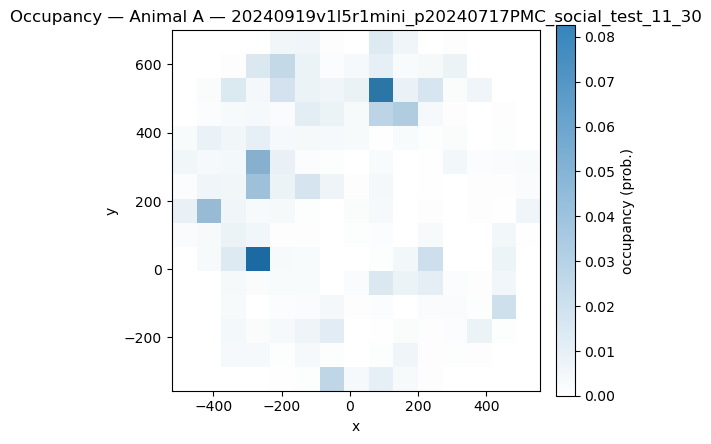

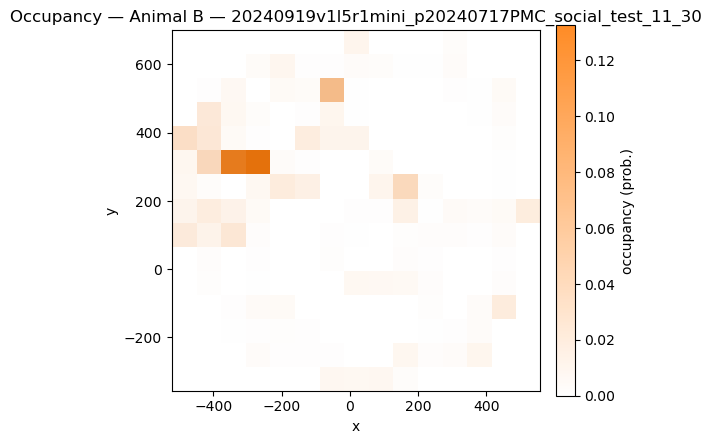

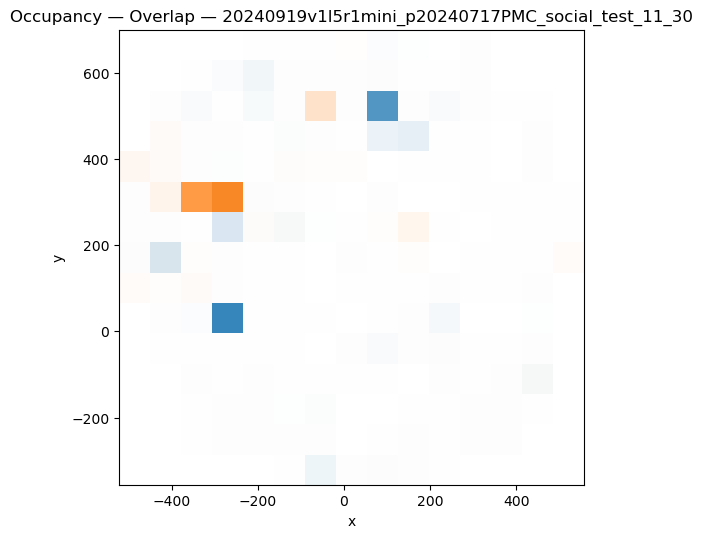

In [60]:
occ = plot_com_occupancy_heatmaps(
    base_path=p,
    bins=15,                 # or (120,120)
    px_to_mm=None,            # set to your scale if you want mm on axes
    animal_colors=('C0','C1'),
    save=False,
    show=True
)


In [84]:
import os
import numpy as np
import scipy.io as sio
import matplotlib.pyplot as plt
import matplotlib as mpl
import matplotlib.colors as mcolors
from scipy.ndimage import gaussian_filter
from matplotlib.patches import Patch

def plot_com_occupancy_heatmaps(
    base_path,
    pred_folder='DANNCE/predict00',
    com_dir='yolo_tracking/predict_train_lone_social_retrain_0917',
    vis_dir='COM/predict00/vis',
    pair=(0, 1),
    bins=100,                 # int or (nx, ny)
    px_to_mm=None,            # scalar to label axes in mm
    normalize=True,           # prob vs counts (for single-animal maps)
    smooth_sigma=1.0,         # Gaussian blur in bin units (0 disables)
    vmax_pct=99.5,            # single-animal color scaling (nonzero percentile)
    gamma=0.6,                # single-animal gamma for low-density lift
    # overlap intensity (built from RAW, not smoothed)
    overlap_low_pct=70,       # drop low tail
    overlap_high_pct=99.5,    # cap high tail
    overlap_gamma=0.8,        # nonlinearity for overlap intensity
    overlap_imax=0.85,        # max intensity per animal in overlap (0..1)
    animal_colors=('C0','C1'),
    titles=('Occupancy — Animal A','Occupancy — Animal B','Occupancy — Overlap'),
    filenames=('occ_A.png','occ_B.png','occ_overlap.png'),
    show=True,
    save=False
):
    # ---------- load COM → (T,2,N) ----------
    primary = os.path.join(base_path, pred_folder, 'com3d_used.mat')
    fallback = os.path.join(base_path, com_dir, 'com3d0.mat')
    com_file = primary if os.path.isfile(primary) else fallback
    raw = sio.loadmat(com_file).get('com')
    if raw is None:
        raise KeyError(f"'com' not found in {com_file}")

    if raw.ndim == 3 and raw.shape[1] == 3:
        com_xy = raw[:, :2, :]
    elif raw.ndim == 3 and raw.shape[1] == 2:
        com_xy = raw
    elif raw.ndim == 2 and raw.shape[1] % 3 == 0:
        N = raw.shape[1] // 3
        com_xy = raw.reshape(-1, 3, N)[:, :2, :]
    elif raw.ndim == 2 and raw.shape[1] % 2 == 0:
        N = raw.shape[1] // 2
        com_xy = raw.reshape(-1, 2, N)
    else:
        raise ValueError(f"Unexpected COM shape {raw.shape}")

    T, _, N = com_xy.shape
    if max(pair) >= N:
        raise ValueError(f"Pair index {pair} exceeds #animals {N}")

    x1, y1 = com_xy[:, 0, pair[0]], com_xy[:, 1, pair[0]]
    x2, y2 = com_xy[:, 0, pair[1]], com_xy[:, 1, pair[1]]
    v = np.isfinite(x1) & np.isfinite(y1) & np.isfinite(x2) & np.isfinite(y2)
    x1, y1, x2, y2 = x1[v], y1[v], x2[v], y2[v]

    if px_to_mm is not None:
        s = float(px_to_mm)
        x1, y1, x2, y2 = x1*s, y1*s, x2*s, y2*s
        ulabel = ' (mm)'
    else:
        ulabel = ''

    if x1.size == 0 or x2.size == 0:
        raise ValueError("No valid positions for one or both animals.")

    # ---------- shared bin edges ----------
    xmin = np.nanmin([x1.min(), x2.min()])
    xmax = np.nanmax([x1.max(), x2.max()])
    ymin = np.nanmin([y1.min(), y2.min()])
    ymax = np.nanmax([y1.max(), y2.max()])

    if isinstance(bins, int):
        nx = ny = int(bins)
    else:
        nx, ny = int(bins[0]), int(bins[1])

    xedges = np.linspace(xmin, xmax, nx+1)
    yedges = np.linspace(ymin, ymax, ny+1)
    extent = (xedges[0], xedges[-1], yedges[0], yedges[-1])

    # ---------- histograms (keep RAW for overlap) ----------
    H1_raw, _, _ = np.histogram2d(x1, y1, bins=[xedges, yedges])
    H2_raw, _, _ = np.histogram2d(x2, y2, bins=[xedges, yedges])

    # copies for single-animal panels
    H1, H2 = H1_raw.copy(), H2_raw.copy()
    if smooth_sigma and smooth_sigma > 0:
        H1 = gaussian_filter(H1, sigma=smooth_sigma, mode='nearest')
        H2 = gaussian_filter(H2, sigma=smooth_sigma, mode='nearest')

    # ---------- single-animal scaling ----------
    if normalize:
        s1, s2 = H1.sum(), H2.sum()
        if s1 > 0: H1 = H1 / s1
        if s2 > 0: H2 = H2 / s2
        cbar_label = 'occupancy (prob.)'
    else:
        cbar_label = 'occupancy (frames)'

    def _scale_for_display(H):
        nz = H[H > 0]
        vmax = np.percentile(nz, vmax_pct) if nz.size else 1.0
        X = np.clip(H / (vmax + 1e-12), 0, 1) ** gamma
        return X, vmax

    A1_disp, vmax1 = _scale_for_display(H1)
    A2_disp, vmax2 = _scale_for_display(H2)

    # ---------- figure A ----------
    norm1 = mpl.colors.Normalize(vmin=0, vmax=vmax1)
    figA, axA = plt.subplots(figsize=(5.2, 5.2))
    imA = axA.imshow(H1.T, origin='lower', extent=extent, cmap='Blues', norm=norm1, interpolation='nearest')
    axA.set_aspect('equal'); axA.set_title(titles[0] + f' — {os.path.basename(base_path)}')
    axA.set_xlabel('x'+ulabel); axA.set_ylabel('y'+ulabel)
    cbarA = figA.colorbar(imA, ax=axA, fraction=0.046, pad=0.04); cbarA.set_label(cbar_label)

    # ---------- figure B ----------
    norm2 = mpl.colors.Normalize(vmin=0, vmax=vmax2)
    figB, axB = plt.subplots(figsize=(5.2, 5.2))
    imB = axB.imshow(H2.T, origin='lower', extent=extent, cmap='Oranges', norm=norm2, interpolation='nearest')
    axB.set_aspect('equal'); axB.set_title(titles[1] + f' — {os.path.basename(base_path)}')
    axB.set_xlabel('x'+ulabel); axB.set_ylabel('y'+ulabel)
    cbarB = figB.colorbar(imB, ax=axB, fraction=0.046, pad=0.04); cbarB.set_label(cbar_label)

    # ---------- overlap (order-independent screen blend) ----------
    def _intensity_from_raw(H_raw, low_pct, high_pct, gamma, imax):
        nz = H_raw[H_raw > 0]
        if nz.size == 0:
            return np.zeros_like(H_raw, dtype=float)
        lo = np.percentile(nz, low_pct)
        hi = np.percentile(nz, high_pct)
        I = (H_raw - lo) / (hi - lo + 1e-12)
        I = np.clip(I, 0, 1) ** gamma
        return np.clip(I * imax, 0.0, 1.0)  # intensity in [0, imax]

    I1 = _intensity_from_raw(H1_raw, overlap_low_pct, overlap_high_pct, overlap_gamma, overlap_imax)
    I2 = _intensity_from_raw(H2_raw, overlap_low_pct, overlap_high_pct, overlap_gamma, overlap_imax)

    qA = np.percentile(I1[I1>0], 85)
    qB = np.percentile(I2[I2>0], 85)
    _keep = (I1 >= qA) | (I2 >= qB)   # keep strong bins only

    c1 = np.array(mcolors.to_rgb(animal_colors[0]))
    c2 = np.array(mcolors.to_rgb(animal_colors[1]))

    # screen blend over white background (order-independent):
    # C = 1 - (1 - I1*c1) * (1 - I2*c2)
    # RGB = 1.0 - (1.0 - I1[..., None] * c1) * (1.0 - I2[..., None] * c2)
    # Amax = np.maximum(I1, I2)[..., None]           # per-pixel total intensity
    # RGB  = RGB * Amax + (1 - Amax) * 1.0           # composite onto white

    # RGB = np.clip(RGB, 0.0, 1.0)
    # RGB_img = RGB.transpose(1, 0, 2)  # (ny, nx, 3) for imshow

    tot = I1 + I2
    mix = np.divide(I2, tot + 1e-12)                 # 0→A, 1→B
    col = (1 - mix)[..., None]*c1 + mix[..., None]*c2
    sat = np.abs(I1 - I2) / (tot + 1e-12)            # exclusivity
    val = np.clip(tot / (np.percentile(tot[tot>0], 99.5)+1e-12), 0, 1)

    

    # desaturate where both visit (overlap), brighten with total intensity
    col = (1 - sat[..., None])*1.0 + sat[..., None]*col
    RGB = (1 - val[..., None])*1.0 + val[..., None]*col
    RGB_img = RGB.transpose(1,0,2)
    RGB_img[~_keep.T] = 1.0          # whiten weak bins → clean sparse map



    # ---------- overlap (simple transparent overlay) ----------
    figC, axC = plt.subplots(figsize=(6.0, 6.0))
    axC.set_aspect('equal', 'box')
    axC.set_facecolor('white')
    axC.set_title(titles[2] + f' — {os.path.basename(base_path)}')
    axC.set_xlabel('x' + ulabel); axC.set_ylabel('y' + ulabel)

    # mask zeros so background stays white
    H1m = np.ma.masked_less_equal(H1, 0)
    H2m = np.ma.masked_less_equal(H2, 0)

    # reuse the same scaling as single panels for consistency
    axC.imshow(H1m.T, origin='lower', extent=extent, cmap='Blues',   norm=norm1,
            interpolation='nearest', alpha=0.55)
    axC.imshow(H2m.T, origin='lower', extent=extent, cmap='Oranges', norm=norm2,
            interpolation='nearest', alpha=0.55)

    # figC, axC = plt.subplots(figsize=(6.0, 6.0))
    # axC.imshow(RGB_img, origin='lower', extent=extent, interpolation='nearest')
    # axC.set_aspect('equal', 'box')
    # axC.set_title(titles[2] + f' — {os.path.basename(base_path)}')
    # axC.set_xlabel('x'+ulabel); axC.set_ylabel('y'+ulabel)
    # axC.legend([Patch(facecolor=animal_colors[0]), Patch(facecolor=animal_colors[1])],
    #        ['Animal A', 'Animal B'], loc='upper right', frameon=True, fontsize='small')

    if save:
        out_dir = os.path.join(base_path, vis_dir); os.makedirs(out_dir, exist_ok=True)
        figA.tight_layout(); figB.tight_layout(); figC.tight_layout()
        figA.savefig(os.path.join(out_dir, filenames[0]), dpi=300)
        figB.savefig(os.path.join(out_dir, filenames[1]), dpi=300)
        figC.savefig(os.path.join(out_dir, filenames[2]), dpi=300)

    if not show:
        plt.close(figA); plt.close(figB); plt.close(figC)

    return {
        'H1': H1, 'H2': H2,
        'H1_raw': H1_raw, 'H2_raw': H2_raw,
        'xedges': xedges, 'yedges': yedges, 'extent': extent,
        'vmax1': vmax1, 'vmax2': vmax2
    }


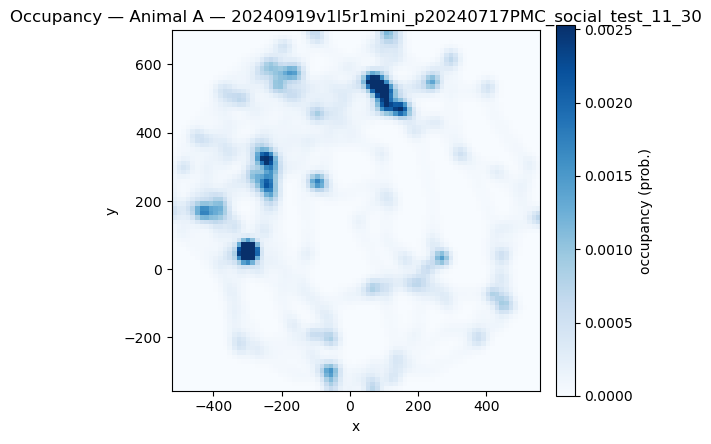

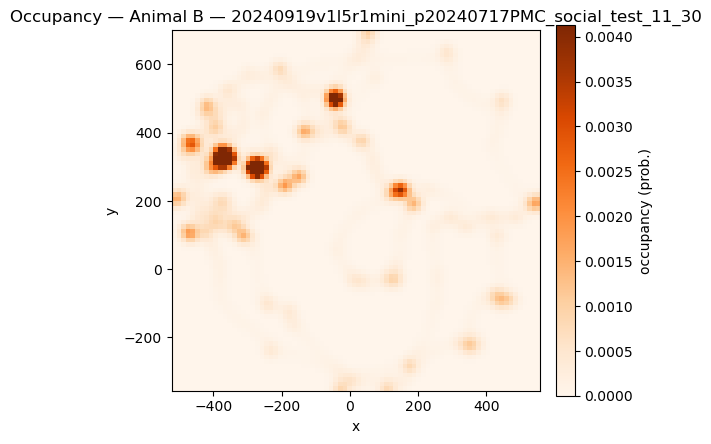

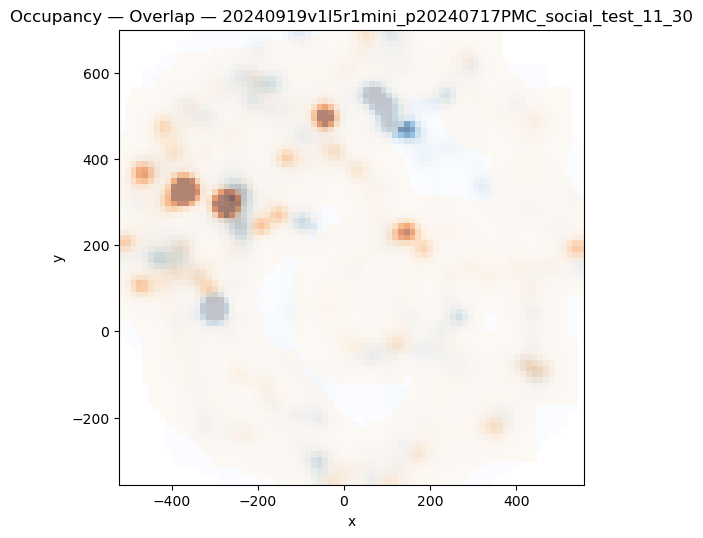

In [ ]:
occ = plot_com_occupancy_heatmaps(
    base_path=p,
    bins=80,              # fewer bins → higher counts per bin
    normalize=True,       # keep prob; contrast handles small values
    smooth_sigma=1.2,     # light blur for coherence
    vmax_pct=99.5,        # clip outliers
    gamma=0.65,           # lift low-density regions
    animal_colors=('C0','C1'),
    show=True, save=False
)


In [86]:
import os
import numpy as np
import scipy.io as sio
import matplotlib.pyplot as plt
import matplotlib as mpl
import matplotlib.colors as mcolors
from scipy.ndimage import gaussian_filter
from matplotlib.patches import Patch

def plot_com_occupancy_heatmaps(
    base_path,
    pred_folder='DANNCE/predict00',
    com_dir='yolo_tracking/predict_train_lone_social_retrain_0917',
    vis_dir='COM/predict00/vis',
    pair=(0, 1),
    bins=100,                 # int or (nx, ny)
    px_to_mm=None,            # scalar to label axes in mm
    normalize=True,           # prob vs counts (for single-animal maps)
    smooth_sigma=1.0,         # Gaussian blur in bin units (0 disables)
    vmax_pct=99.5,            # single-animal color scaling (nonzero percentile)
    gamma=0.6,                # single-animal gamma for low-density lift
    # overlap intensity (built from RAW, not smoothed)
    overlap_low_pct=70,       # drop low tail
    overlap_high_pct=99.5,    # cap high tail
    overlap_gamma=0.8,        # nonlinearity for overlap intensity
    overlap_imax=0.85,        # max intensity per animal in overlap (0..1)
    animal_colors=('C0','C1'),
    titles=('Occupancy — Animal A','Occupancy — Animal B','Occupancy — Overlap'),
    filenames=('occ_A.png','occ_B.png','occ_overlap.png'),
    show=True,
    save=False,
    # --- new poster options ---
    layout='separate',        # 'separate' (old behavior) or 'triptych' (side-by-side)
    poster=True,              # minimal markings if True (used only when layout='triptych')
    show_ticks=False,         # hide tick marks/labels in poster mode
    show_colorbars=False,     # hide colorbars in poster mode
    panel_labels=('A','B','A∩B'),
    triptych_filename='occ_triptych.png',
):
    # ---------- load COM → (T,2,N) ----------
    primary = os.path.join(base_path, pred_folder, 'com3d_used.mat')
    fallback = os.path.join(base_path, com_dir, 'com3d0.mat')
    com_file = primary if os.path.isfile(primary) else fallback
    raw = sio.loadmat(com_file).get('com')
    if raw is None:
        raise KeyError(f"'com' not found in {com_file}")

    if raw.ndim == 3 and raw.shape[1] == 3:
        com_xy = raw[:, :2, :]
    elif raw.ndim == 3 and raw.shape[1] == 2:
        com_xy = raw
    elif raw.ndim == 2 and raw.shape[1] % 3 == 0:
        N = raw.shape[1] // 3
        com_xy = raw.reshape(-1, 3, N)[:, :2, :]
    elif raw.ndim == 2 and raw.shape[1] % 2 == 0:
        N = raw.shape[1] // 2
        com_xy = raw.reshape(-1, 2, N)
    else:
        raise ValueError(f"Unexpected COM shape {raw.shape}")

    T, _, N = com_xy.shape
    if max(pair) >= N:
        raise ValueError(f"Pair index {pair} exceeds #animals {N}")

    x1, y1 = com_xy[:, 0, pair[0]], com_xy[:, 1, pair[0]]
    x2, y2 = com_xy[:, 0, pair[1]], com_xy[:, 1, pair[1]]
    v = np.isfinite(x1) & np.isfinite(y1) & np.isfinite(x2) & np.isfinite(y2)
    x1, y1, x2, y2 = x1[v], y1[v], x2[v], y2[v]

    ulabel = ''
    if px_to_mm is not None:
        s = float(px_to_mm)
        x1, y1, x2, y2 = x1*s, y1*s, x2*s, y2*s
        ulabel = ' (mm)'

    if x1.size == 0 or x2.size == 0:
        raise ValueError("No valid positions for one or both animals.")

    # ---------- shared bin edges ----------
    xmin = float(np.nanmin([x1.min(), x2.min()]))
    xmax = float(np.nanmax([x1.max(), x2.max()]))
    ymin = float(np.nanmin([y1.min(), y2.min()]))
    ymax = float(np.nanmax([y1.max(), y2.max()]))

    if isinstance(bins, int):
        nx = ny = int(bins)
    else:
        nx, ny = int(bins[0]), int(bins[1])

    xedges = np.linspace(xmin, xmax, nx+1)
    yedges = np.linspace(ymin, ymax, ny+1)
    extent = (xedges[0], xedges[-1], yedges[0], yedges[-1])

    # ---------- histograms (keep RAW for overlap) ----------
    H1_raw, _, _ = np.histogram2d(x1, y1, bins=[xedges, yedges])
    H2_raw, _, _ = np.histogram2d(x2, y2, bins=[xedges, yedges])

    H1, H2 = H1_raw.copy(), H2_raw.copy()
    if smooth_sigma and smooth_sigma > 0:
        H1 = gaussian_filter(H1, sigma=smooth_sigma, mode='nearest')
        H2 = gaussian_filter(H2, sigma=smooth_sigma, mode='nearest')

    # ---------- single-animal scaling ----------
    if normalize:
        s1, s2 = H1.sum(), H2.sum()
        if s1 > 0: H1 /= s1
        if s2 > 0: H2 /= s2
        cbar_label = 'occupancy (prob.)'
    else:
        cbar_label = 'occupancy (frames)'

    def _scale_for_display(H):
        nz = H[H > 0]
        vmax = np.percentile(nz, vmax_pct) if nz.size else 1.0
        return mpl.colors.Normalize(vmin=0, vmax=vmax)

    norm1 = _scale_for_display(H1)
    norm2 = _scale_for_display(H2)

    # ---------- overlap: simple transparent overlay (clean + robust) ----------
    H1m = np.ma.masked_less_equal(H1, 0)
    H2m = np.ma.masked_less_equal(H2, 0)

    # ---------- draw ----------
    if layout == 'separate':
        # old behavior: three figures
        figA, axA = plt.subplots(figsize=(5.2, 5.2))
        imA = axA.imshow(H1.T, origin='lower', extent=extent, cmap='Blues', norm=norm1, interpolation='nearest')
        axA.set_aspect('equal'); axA.set_title(titles[0] + f' — {os.path.basename(base_path)}')
        axA.set_xlabel('x'+ulabel); axA.set_ylabel('y'+ulabel)
        cbarA = figA.colorbar(imA, ax=axA, fraction=0.046, pad=0.04); cbarA.set_label(cbar_label)

        figB, axB = plt.subplots(figsize=(5.2, 5.2))
        imB = axB.imshow(H2.T, origin='lower', extent=extent, cmap='Oranges', norm=norm2, interpolation='nearest')
        axB.set_aspect('equal'); axB.set_title(titles[1] + f' — {os.path.basename(base_path)}')
        axB.set_xlabel('x'+ulabel); axB.set_ylabel('y'+ulabel)
        cbarB = figB.colorbar(imB, ax=axB, fraction=0.046, pad=0.04); cbarB.set_label(cbar_label)

        figC, axC = plt.subplots(figsize=(6.0, 6.0))
        axC.set_aspect('equal', 'box'); axC.set_facecolor('white')
        axC.set_title(titles[2] + f' — {os.path.basename(base_path)}')
        axC.set_xlabel('x' + ulabel); axC.set_ylabel('y' + ulabel)
        axC.imshow(H1m.T, origin='lower', extent=extent, cmap='Blues',   norm=norm1, interpolation='nearest', alpha=0.55)
        axC.imshow(H2m.T, origin='lower', extent=extent, cmap='Oranges', norm=norm2, interpolation='nearest', alpha=0.55)

        if save:
            out_dir = os.path.join(base_path, vis_dir); os.makedirs(out_dir, exist_ok=True)
            figA.tight_layout(); figB.tight_layout(); figC.tight_layout()
            figA.savefig(os.path.join(out_dir, filenames[0]), dpi=300)
            figB.savefig(os.path.join(out_dir, filenames[1]), dpi=300)
            figC.savefig(os.path.join(out_dir, filenames[2]), dpi=300)

        if not show:
            plt.close(figA); plt.close(figB); plt.close(figC)

    elif layout == 'triptych':
        # poster-ready: a single row, minimal markings
        # small, consistent fonts; clean background
        if poster:
            mpl.rcParams.update({
                "axes.edgecolor": "0.15",
                "axes.linewidth": 0.6,
                "font.size": 9,
                "axes.titlesize": 10,
                "xtick.major.size": 0, "ytick.major.size": 0,
            })

        fig, axes = plt.subplots(1, 3, figsize=(14.4, 4.8), constrained_layout=True)
        axA, axB, axC = axes

        # A
        imA = axA.imshow(H1.T, origin='lower', extent=extent, cmap='Blues', norm=norm1, interpolation='nearest')
        axA.set_aspect('equal'); 
        # B
        imB = axB.imshow(H2.T, origin='lower', extent=extent, cmap='Oranges', norm=norm2, interpolation='nearest')
        axB.set_aspect('equal')
        # C (overlap)
        axC.imshow(H1m.T, origin='lower', extent=extent, cmap='Blues',   norm=norm1, interpolation='nearest', alpha=0.55)
        axC.imshow(H2m.T, origin='lower', extent=extent, cmap='Oranges', norm=norm2, interpolation='nearest', alpha=0.55)
        axC.set_aspect('equal')

        # unified limits and minimal axes
        for ax in axes:
            ax.set_xlim(extent[0], extent[1]); ax.set_ylim(extent[2], extent[3])
            if poster:
                ax.set_title('')
                if not show_ticks:
                    ax.set_xticks([]); ax.set_yticks([])
                ax.spines['top'].set_visible(False)
                ax.spines['right'].set_visible(False)
                ax.spines['left'].set_visible(False)
                ax.spines['bottom'].set_visible(False)
            else:
                ax.set_xlabel('x'+ulabel); ax.set_ylabel('y'+ulabel)

        # tiny in-panel labels (non-intrusive)
        if panel_labels:
            for lab, ax in zip(panel_labels, axes):
                ax.text(0.02, 0.98, lab, transform=ax.transAxes, ha='left', va='top',
                        fontsize=10, fontweight='bold', color='0.15')

        # optional colorbars (off by default)
        if show_colorbars:
            # narrow colorbars beneath A and B only
            from mpl_toolkits.axes_grid1 import make_axes_locatable
            for ax, im in [(axA, imA), (axB, imB)]:
                divider = make_axes_locatable(ax)
                cax = divider.append_axes("bottom", size="3%", pad=0.5)
                cb = fig.colorbar(im, cax=cax, orientation='horizontal')
                cb.set_label(cbar_label)

        if save:
            out_dir = os.path.join(base_path, vis_dir); os.makedirs(out_dir, exist_ok=True)
            fig.savefig(os.path.join(out_dir, triptych_filename), dpi=300, bbox_inches='tight')

        if not show:
            plt.close(fig)

    else:
        raise ValueError("layout must be 'separate' or 'triptych'")

    return {
        'H1': H1, 'H2': H2,
        'H1_raw': H1_raw, 'H2_raw': H2_raw,
        'xedges': xedges, 'yedges': yedges, 'extent': extent,
        'norm1': norm1, 'norm2': norm2
    }


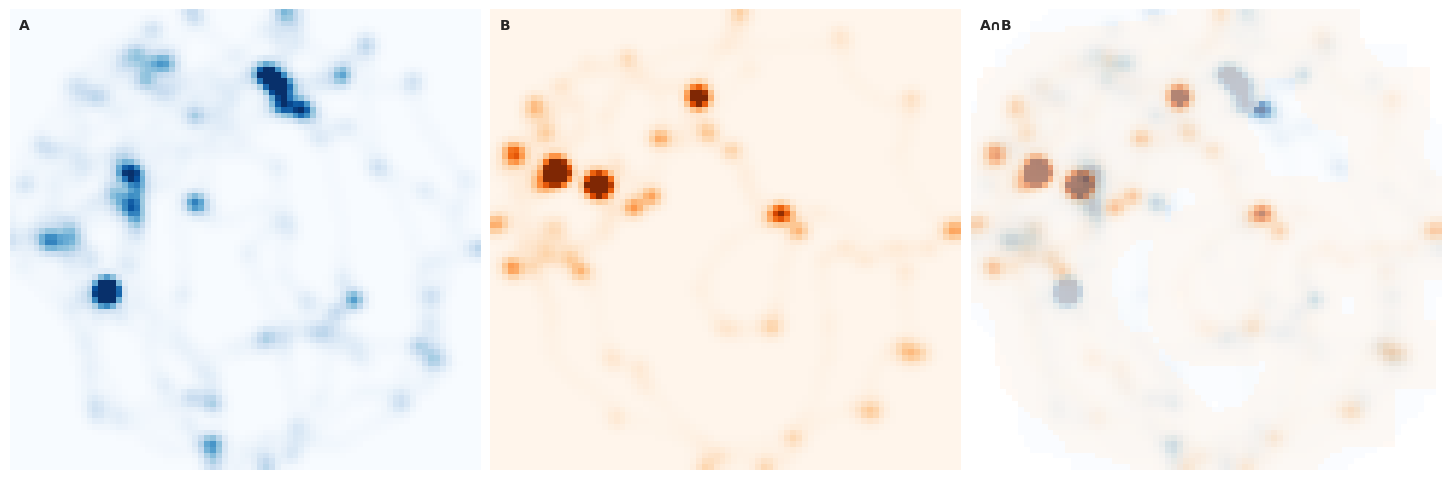

In [87]:
occ = plot_com_occupancy_heatmaps(
    base_path=p,
    bins=80,
    normalize=True,
    smooth_sigma=1.2,
    vmax_pct=99.5, gamma=0.65,
    overlap_low_pct=75, overlap_high_pct=99.2,
    overlap_gamma=0.9, overlap_imax=0.8,
    animal_colors=('C0','C1'),
    layout='triptych',          # <- side-by-side
    poster=True,                # <- minimal markings
    show_ticks=False,
    show_colorbars=False,
    save=False, show=True
)


In [97]:
import os, numpy as np, scipy.io as sio
import matplotlib.pyplot as plt
from matplotlib.collections import LineCollection
from matplotlib.lines import Line2D
import matplotlib.cm as cm
from scipy.ndimage import gaussian_filter

# ---------- small COM loader ----------
def _load_com_xy(base_path, pred_folder='DANNCE/predict00',
                 com_dir='yolo_tracking/predict_train_lone_social_retrain_0917'):
    p1 = os.path.join(base_path, pred_folder, 'com3d_used.mat')
    p2 = os.path.join(base_path, com_dir, 'com3d0.mat')
    com_file = p1 if os.path.isfile(p1) else p2
    raw = sio.loadmat(com_file).get('com')
    if raw is None:
        raise KeyError(f"'com' not found in {com_file}")
    if raw.ndim == 3 and raw.shape[1] == 3:  # (T,3,N)
        com_xy = raw[:, :2, :]
    elif raw.ndim == 3 and raw.shape[1] == 2:  # (T,2,N)
        com_xy = raw
    elif raw.ndim == 2 and raw.shape[1] % 3 == 0:
        N = raw.shape[1] // 3
        com_xy = raw.reshape(-1, 3, N)[:, :2, :]
    elif raw.ndim == 2 and raw.shape[1] % 2 == 0:
        N = raw.shape[1] // 2
        com_xy = raw.reshape(-1, 2, N)
    else:
        raise ValueError(f"Unexpected COM shape {raw.shape}")
    return com_xy

# ---------- events (same logic spirit as your function, compact) ----------
def _meeting_events(x1,y1,x2,y2,fps,dist_thresh=120.0,min_len=15,gap=10,win_pad_s=0.75):
    T = len(x1)
    valid = np.isfinite(x1)&np.isfinite(y1)&np.isfinite(x2)&np.isfinite(y2)
    t = np.arange(T)/float(fps)
    dist = np.full(T, np.nan)
    dist[valid] = np.hypot(x1[valid]-x2[valid], y1[valid]-y2[valid])
    close = np.isfinite(dist) & (dist <= dist_thresh)

    # segments
    starts = np.flatnonzero(~np.concatenate(([False], close[:-1])) & close)
    ends   = np.flatnonzero(close & ~np.concatenate((close[1:], [False])))
    segs = np.column_stack([starts, ends]) if starts.size else np.empty((0,2), int)
    if segs.size:
        # length filter
        L = segs[:,1]-segs[:,0]+1
        segs = segs[L>=min_len]
        # merge short gaps
        merged=[segs[0].tolist()] if segs.size else []
        for s,e in segs[1:]:
            if s-merged[-1][1]-1 <= gap: merged[-1][1]=e
            else: merged.append([s,e])
        segs = np.asarray(merged, int) if merged else np.empty((0,2), int)

    pad = int(round(win_pad_s*fps))
    events=[]
    for s,e in segs:
        w = slice(s,e+1); idx_mid = (s+e)//2
        if np.any(np.isfinite(dist[w])):
            idx_mid = s + int(np.nanargmin(dist[w]))
        events.append(dict(start=s,end=e,rep=idx_mid,
                           t0=t[s],t1=t[e],trep=t[idx_mid],
                           dmin=float(dist[idx_mid])))
    return t, dist, valid, events, pad

# ---------- tiny helpers for lines ----------
def _seg_lines(x,y,mask_pairs):
    pts = np.column_stack([x,y])
    seg = np.stack([pts[:-1], pts[1:]], axis=1)
    return seg[mask_pairs]

# ---------- main: 2×2 composite ----------
def plot_social_quadrant(base_path,
                         pair=(0,1), fps=30.0, dist_thresh=120.0,
                         px_to_mm=None,
                         animal_colors=('C0','C1'),
                         smooth_xy=None,            # e.g., 1.0 to lightly denoise XY occupancy look
                         show=True, save=False, out_png='quad.png'):
    com = _load_com_xy(base_path)
    T,_,N = com.shape
    if max(pair)>=N: raise ValueError("pair index exceeds available animals")
    x1,y1 = com[:,0,pair[0]], com[:,1,pair[0]]
    x2,y2 = com[:,0,pair[1]], com[:,1,pair[1]]

    if px_to_mm is not None:
        s=float(px_to_mm)
        x1*=s; y1*=s; x2*=s; y2*=s
        xlab, ylab = 'x (mm)', 'y (mm)'
        dlab='Distance (mm)'
    else:
        xlab, ylab = 'x', 'y'
        dlab='distance (xy)'

    # events + dist
    t, dist, valid, events, pad = _meeting_events(x1,y1,x2,y2,fps,dist_thresh)

    # unified limits
    xmin, xmax = np.nanmin([x1,x2]), np.nanmax([x1,x2])
    ymin, ymax = np.nanmin([y1,y2]), np.nanmax([y1,y2])

    # figure
    fig = plt.figure(figsize=(12,6.8))
    gs = fig.add_gridspec(2,2, width_ratios=[1.2,1], height_ratios=[1,1], hspace=0.35, wspace=0.15)
    ax_d_full = fig.add_subplot(gs[0,0])  # TL: full distance (plain)
    ax_xy_plain= fig.add_subplot(gs[0,1]) # TR: plain XY
    ax_d_evt  = fig.add_subplot(gs[1,0])  # BL: distance with spans
    ax_xy_evt = fig.add_subplot(gs[1, 1])  # BR: XY with highlighted events


    # ---- TL: plain distance (no markings) ----
    ax_d_full.plot(t, dist, lw=1.0, color='C0')
    ax_d_full.set_title('Inter-animal COM distance')
    ax_d_full.set_ylabel(dlab)

    # ---- TR: plain XY (two colors, faint alpha) ----
    valid_seg = valid[:-1] & valid[1:]
    if valid_seg.any():
        ax_xy_plain.add_collection(LineCollection(_seg_lines(x1,y1,valid_seg),
                              colors=animal_colors[0], linewidths=1.0, alpha=0.8))
        ax_xy_plain.add_collection(LineCollection(_seg_lines(x2,y2,valid_seg),
                              colors=animal_colors[1], linewidths=1.0, alpha=0.8))
    # mark first valid points
    if valid.any():
        f0 = np.flatnonzero(valid)[0]
        ax_xy_plain.plot([x1[f0]],[y1[f0]],'o',ms=3,mec='none',mfc=animal_colors[0])
        ax_xy_plain.plot([x2[f0]],[y2[f0]],'o',ms=3,mec='none',mfc=animal_colors[1])
    ax_xy_plain.set_xlim(xmin, xmax); ax_xy_plain.set_ylim(ymin, ymax)
    ax_xy_plain.set_aspect('equal','box')
    ax_xy_plain.set_title(os.path.basename(base_path))
    ax_xy_plain.set_xlabel(xlab); ax_xy_plain.set_ylabel(ylab)
    ax_xy_plain.legend([Line2D([0],[0],color=animal_colors[0],lw=2),
                        Line2D([0],[0],color=animal_colors[1],lw=2)],
                       [f'COM{pair[0]+1}', f'COM{pair[1]+1}'],
                       fontsize='small', loc='best')

    # ---- BL: distance with shaded events + threshold ----
    ax_d_evt.plot(t, dist, lw=1.2, color='0.15')
    ax_d_evt.axhline(dist_thresh, ls='--', lw=1.0, color='k', alpha=0.7)
    y_text = 0.9*np.nanmax(dist) if np.any(np.isfinite(dist)) else dist_thresh
    cmap = cm.get_cmap('tab10', max(1,len(events)))
    for k,ev in enumerate(events, start=1):
        s,e,rep = ev['start'], ev['end'], ev['rep']
        ax_d_evt.axvspan(t[s], t[e], color=cmap(k-1), alpha=0.18)
        ax_d_evt.text(t[rep], y_text, str(k), ha='center', va='center', fontsize=9,
                      bbox=dict(boxstyle="circle,pad=0.15", fc='white', ec=cmap(k-1), lw=0.9, alpha=0.9))
    ax_d_evt.set_xlabel('time (s)'); ax_d_evt.set_ylabel(dlab)
    ax_d_evt.set_title('Inter-animal distance (xy)')

    # ---- BR: XY with highlighted event windows + numbers ----
    # faint base
    if valid_seg.any():
        ax_xy_evt.add_collection(LineCollection(_seg_lines(x1,y1,valid_seg),
                              colors=animal_colors[0], linewidths=1.0, alpha=0.18))
        ax_xy_evt.add_collection(LineCollection(_seg_lines(x2,y2,valid_seg),
                              colors=animal_colors[1], linewidths=1.0, alpha=0.18))
    # highlights
    for k,ev in enumerate(events, start=1):
        s = max(0, ev['start']-pad); e = min(T-1, ev['end']+pad)
        win = np.zeros_like(valid_seg); win[s:e]=True
        mask = valid_seg & win
        col = cmap(k-1)
        if mask.any():
            ax_xy_evt.add_collection(LineCollection(_seg_lines(x1,y1,mask),
                                  colors=col, linewidths=2.2, alpha=0.95))
            ax_xy_evt.add_collection(LineCollection(_seg_lines(x2,y2,mask),
                                  colors=col, linewidths=2.2, alpha=0.95))
        # number at midpoint between animals
        idx = ev['rep']
        if 0<=idx<T and valid[idx]:
            mx = 0.5*(x1[idx]+x2[idx]); my = 0.5*(y1[idx]+y2[idx])
            ax_xy_evt.text(mx, my, str(k), fontsize=9, ha='center', va='center',
                           bbox=dict(boxstyle="circle,pad=0.15", fc='white', ec=col, lw=0.9, alpha=0.95))
    ax_xy_evt.set_xlim(xmin, xmax); ax_xy_evt.set_ylim(ymin, ymax)
    ax_xy_evt.set_aspect('equal','box')
    ax_xy_evt.set_xlabel(xlab); ax_xy_evt.set_ylabel(ylab)
    ax_xy_evt.set_title(os.path.basename(base_path))

    if save:
        fig.tight_layout()
        fig.savefig(os.path.join(base_path, out_png), dpi=300, bbox_inches='tight')
    if not show:
        plt.close(fig)
    return dict(t=t, dist=dist, events=events, valid=valid)


/tmp/ipykernel_184315/2497251653.py:140: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('tab10', max(1,len(events)))


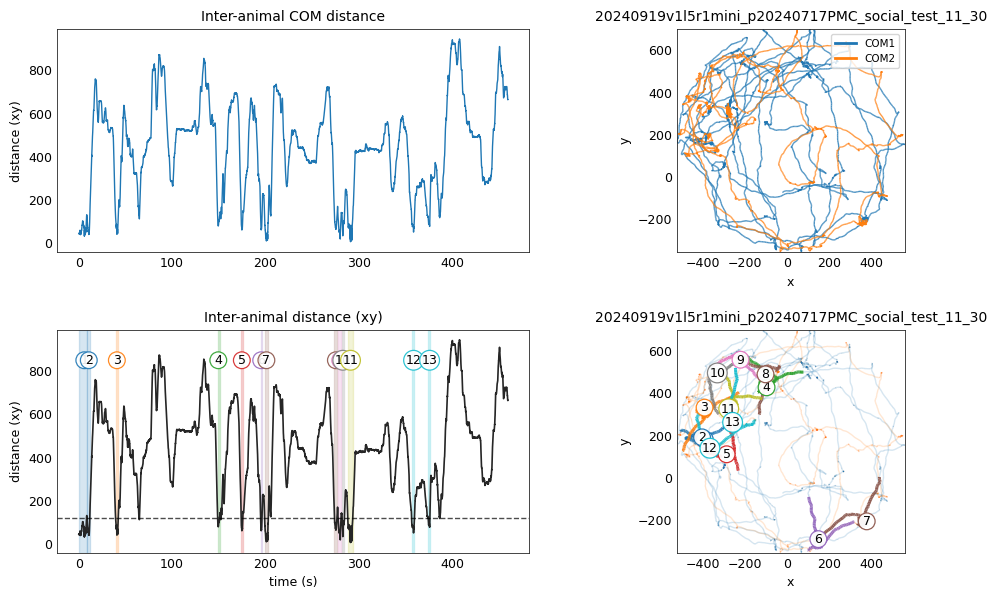

In [98]:
labels = [
    # "/data/big_rim/rsync_dcc_sum/Oct3V1/2025_04_10/20241212V1RE1L23Fmini_p20241212V1BE1L23F",
    # "/data/big_rim/rsync_dcc_sum/Oct3V1/2025_05_01/20250324PMCBmini_psamecageLE2_15_09",
    # "/data/big_rim/rsync_dcc_sum/Oct3V1/2025_03_11/20241224PMCLE1mini_p20240303PMC2_14_44",
    "/data/big_rim/rsync_dcc_sum/Oct3V1/2024_12_18/20240919v1l5r1mini_p20240717PMC_social_test_11_30",
]

for p in labels:
    plot_social_quadrant(p, fps=30.0, dist_thresh=120.0, px_to_mm=None, save=False, show=True)


In [101]:
import os
import numpy as np
import scipy.io as sio
import matplotlib.pyplot as plt
from matplotlib.collections import LineCollection
import matplotlib.cm as cm

def _load_com_xy(base_path,
                 pred_folder='DANNCE/predict00',
                 com_dir='yolo_tracking/predict_train_lone_social_retrain_0917'):
    p1 = os.path.join(base_path, pred_folder, 'com3d_used.mat')
    p2 = os.path.join(base_path, com_dir, 'com3d0.mat')
    com_file = p1 if os.path.isfile(p1) else p2
    raw = sio.loadmat(com_file).get('com')
    if raw is None: raise KeyError(f"'com' not found in {com_file}")
    if raw.ndim == 3 and raw.shape[1] == 3:  # (T,3,N)
        return raw[:, :2, :]
    if raw.ndim == 3 and raw.shape[1] == 2:  # (T,2,N)
        return raw
    if raw.ndim == 2 and raw.shape[1] % 3 == 0:
        N = raw.shape[1] // 3
        return raw.reshape(-1, 3, N)[:, :2, :]
    if raw.ndim == 2 and raw.shape[1] % 2 == 0:
        N = raw.shape[1] // 2
        return raw.reshape(-1, 2, N)
    raise ValueError(f"Unexpected COM shape {raw.shape}")

def _events_from_dist(x1, y1, x2, y2, fps, dist_thresh=120.0,
                      min_len=15, gap=10, pad_s=0.75):
    T = len(x1)
    valid = np.isfinite(x1)&np.isfinite(y1)&np.isfinite(x2)&np.isfinite(y2)
    t = np.arange(T)/float(fps)
    dist = np.full(T, np.nan)
    dist[valid] = np.hypot(x1[valid]-x2[valid], y1[valid]-y2[valid])
    close = np.isfinite(dist) & (dist <= dist_thresh)

    starts = np.flatnonzero(~np.concatenate(([False], close[:-1])) & close)
    ends   = np.flatnonzero(close & ~np.concatenate((close[1:], [False])))
    segs = np.column_stack([starts, ends]) if starts.size else np.empty((0,2), int)
    if segs.size:
        L = segs[:,1]-segs[:,0]+1
        segs = segs[L>=min_len]
        merged=[]
        for s,e in segs:
            if merged and s-merged[-1][1]-1 <= gap: merged[-1][1]=e
            else: merged.append([s,e])
        segs = np.asarray(merged, int) if merged else np.empty((0,2), int)

    events=[]
    for s,e in segs:
        w = slice(s, e+1)
        rep = s + int(np.nanargmin(dist[w])) if np.any(np.isfinite(dist[w])) else (s+e)//2
        events.append(dict(start=s, end=e, rep=rep, t0=t[s], t1=t[e], trep=t[rep]))
    pad = int(round(pad_s*fps))
    return t, dist, valid, events, pad

def _seg_lines(x, y, mask_pairs):
    pts = np.column_stack([x, y])
    seg = np.stack([pts[:-1], pts[1:]], axis=1)
    return seg[mask_pairs]

def plot_social_quad_poster(
    base_path,
    pair=(0,1), fps=30.0, dist_thresh=120.0,
    px_to_mm=None,
    animal_colors=('C0','C1'),
    annotate_meetings=False,         # still honored
    show=True, save=False, out_png='quad_poster.png'
):
    com = _load_com_xy(base_path)
    T, _, N = com.shape
    if max(pair) >= N: raise ValueError("pair index out of range")

    x1,y1 = com[:,0,pair[0]], com[:,1,pair[0]]
    x2,y2 = com[:,0,pair[1]], com[:,1,pair[1]]

    if px_to_mm is not None:
        s=float(px_to_mm); x1*=s; y1*=s; x2*=s; y2*=s
        xlab, ylab_xy, ylab = 'x (mm)', 'y (mm)', 'mm'
    else:
        xlab, ylab_xy, ylab = 'x', 'y', 'mm'

    t, dist, valid, events, pad = _events_from_dist(x1,y1,x2,y2,fps,dist_thresh)
    valid_seg = valid[:-1] & valid[1:]

    xmin, xmax = np.nanmin([x1,x2]), np.nanmax([x1,x2])
    ymin, ymax = np.nanmin([y1,y2]), np.nanmax([y1,y2])

    # tight layout: close gaps
    fig = plt.figure(figsize=(12, 6.4), constrained_layout=True)
    gs = fig.add_gridspec(2,2, width_ratios=[1.2,1.0], height_ratios=[1,1])
    fig.subplots_adjust(hspace=0.12, wspace=0.12)

    ax_d_plain = fig.add_subplot(gs[0,0])
    ax_xy_plain= fig.add_subplot(gs[0,1])
    ax_d_evt   = fig.add_subplot(gs[1,0], sharex=ax_d_plain)  # share x with TL
    ax_xy_evt  = fig.add_subplot(gs[1,1])

    def _min_style(ax, left=False, keep_xticks=False):
        for s in ('top','right'): ax.spines[s].set_visible(False)
        if not keep_xticks:
            ax.tick_params(axis='x', labelbottom=False, length=0)
        ax.tick_params(axis='y', length=(3 if left else 0), labelleft=left)

    # ---- TL: Inter-animal COM distance (with time ticks) ----
    ax_d_plain.plot(t, dist, lw=1.0, color='C0')
    ax_d_plain.set_title('Inter-animal COM distance', fontsize=11, pad=4)
    ax_d_plain.set_ylabel(ylab)
    ax_d_plain.set_xlabel('time (s)')  # show x ticks on top distance too
    _min_style(ax_d_plain, left=True, keep_xticks=True)

    # ---- TR: COM trajectories (plain) ----
    if valid_seg.any():
        ax_xy_plain.add_collection(LineCollection(_seg_lines(x1,y1,valid_seg),
                               colors=animal_colors[0], linewidths=1.0, alpha=0.45))
        ax_xy_plain.add_collection(LineCollection(_seg_lines(x2,y2,valid_seg),
                               colors=animal_colors[1], linewidths=1.0, alpha=0.45))
    ax_xy_plain.set_xlim(xmin, xmax); ax_xy_plain.set_ylim(ymin, ymax)
    ax_xy_plain.set_aspect('equal','box')
    ax_xy_plain.set_title('COM trajectories', fontsize=11, pad=4)
    ax_xy_plain.set_xlabel(xlab); ax_xy_plain.set_ylabel(ylab_xy)
    _min_style(ax_xy_plain, left=False, keep_xticks=False)

    # ---- BL: Inter-animal distance (xy) with events ----
    ax_d_evt.plot(t, dist, lw=1.2, color='0.15')
    ax_d_evt.axhline(dist_thresh, ls='--', lw=0.9, color='k', alpha=0.7)
    cmap = cm.get_cmap('tab10', max(1,len(events)))
    for k, ev in enumerate(events, start=1):
        ax_d_evt.axvspan(ev['t0'], ev['t1'], color=cmap((k-1) % 10), alpha=0.18)
    ax_d_evt.set_title('Inter-animal distance (xy)', fontsize=11, pad=4)
    ax_d_evt.set_xlabel('time (s)'); ax_d_evt.set_ylabel(ylab)
    _min_style(ax_d_evt, left=True, keep_xticks=True)

    # ---- BR: COM trajectories (events) ----
    if valid_seg.any():
        ax_xy_evt.add_collection(LineCollection(_seg_lines(x1,y1,valid_seg),
                             colors=animal_colors[0], linewidths=1.0, alpha=0.15))
        ax_xy_evt.add_collection(LineCollection(_seg_lines(x2,y2,valid_seg),
                             colors=animal_colors[1], linewidths=1.0, alpha=0.15))
        for k, ev in enumerate(events, start=1):
            s = max(0, ev['start']-pad); e = min(T-1, ev['end']+pad)
            win = np.zeros_like(valid_seg); win[s:e]=True
            mask = valid_seg & win
            col = cmap((k-1) % 10)
            if mask.any():
                ax_xy_evt.add_collection(LineCollection(_seg_lines(x1,y1,mask),
                                     colors=col, linewidths=2.2, alpha=0.95))
                ax_xy_evt.add_collection(LineCollection(_seg_lines(x2,y2,mask),
                                     colors=col, linewidths=2.2, alpha=0.95))
            if annotate_meetings:
                idx = ev['rep']
                if 0<=idx<T and valid[idx]:
                    mx = 0.5*(x1[idx]+x2[idx]); my = 0.5*(y1[idx]+y2[idx])
                    ax_xy_evt.text(mx, my, str(k), fontsize=9, ha='center', va='center',
                                   bbox=dict(boxstyle="circle,pad=0.15", fc='white',
                                             ec=col, lw=0.9, alpha=0.95))
    ax_xy_evt.set_xlim(xmin, xmax); ax_xy_evt.set_ylim(ymin, ymax)
    ax_xy_evt.set_aspect('equal','box')
    ax_xy_evt.set_title('COM trajectories (events)', fontsize=11, pad=4)
    ax_xy_evt.set_xlabel(xlab); ax_xy_evt.set_ylabel(ylab_xy)
    _min_style(ax_xy_evt, left=False, keep_xticks=False)

    if save:
        fig.savefig(os.path.join(base_path, out_png), dpi=300, bbox_inches='tight')
    if not show:
        plt.close(fig)

    return dict(time=t, dist=dist, events=events, xy_limits=(xmin,xmax,ymin,ymax))


/tmp/ipykernel_184315/633720330.py:92: UserWarning: This figure was using a layout engine that is incompatible with subplots_adjust and/or tight_layout; not calling subplots_adjust.
  fig.subplots_adjust(hspace=0.12, wspace=0.12)
/tmp/ipykernel_184315/633720330.py:127: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('tab10', max(1,len(events)))


{'time': array([0.00000000e+00, 3.33333333e-02, 6.66666667e-02, ...,
        4.59900000e+02, 4.59933333e+02, 4.59966667e+02]),
 'dist': array([ 41.9101666 ,  42.6954009 ,  41.86765459, ..., 662.92843486,
        662.6376885 , 663.40721173]),
 'events': [{'start': 0,
   'end': 247,
   'rep': 175,
   't0': 0.0,
   't1': 8.233333333333333,
   'trep': 5.833333333333333},
  {'start': 263,
   'end': 350,
   'rep': 319,
   't0': 8.766666666666667,
   't1': 11.666666666666666,
   'trep': 10.633333333333333},
  {'start': 1182,
   'end': 1266,
   'rep': 1222,
   't0': 39.4,
   't1': 42.2,
   'trep': 40.733333333333334},
  {'start': 4465,
   'end': 4524,
   'rep': 4485,
   't0': 148.83333333333334,
   't1': 150.8,
   'trep': 149.5},
  {'start': 5222,
   'end': 5273,
   'rep': 5242,
   't0': 174.06666666666666,
   't1': 175.76666666666668,
   'trep': 174.73333333333332},
  {'start': 5848,
   'end': 5891,
   'rep': 5865,
   't0': 194.93333333333334,
   't1': 196.36666666666667,
   'trep': 195.5},
 

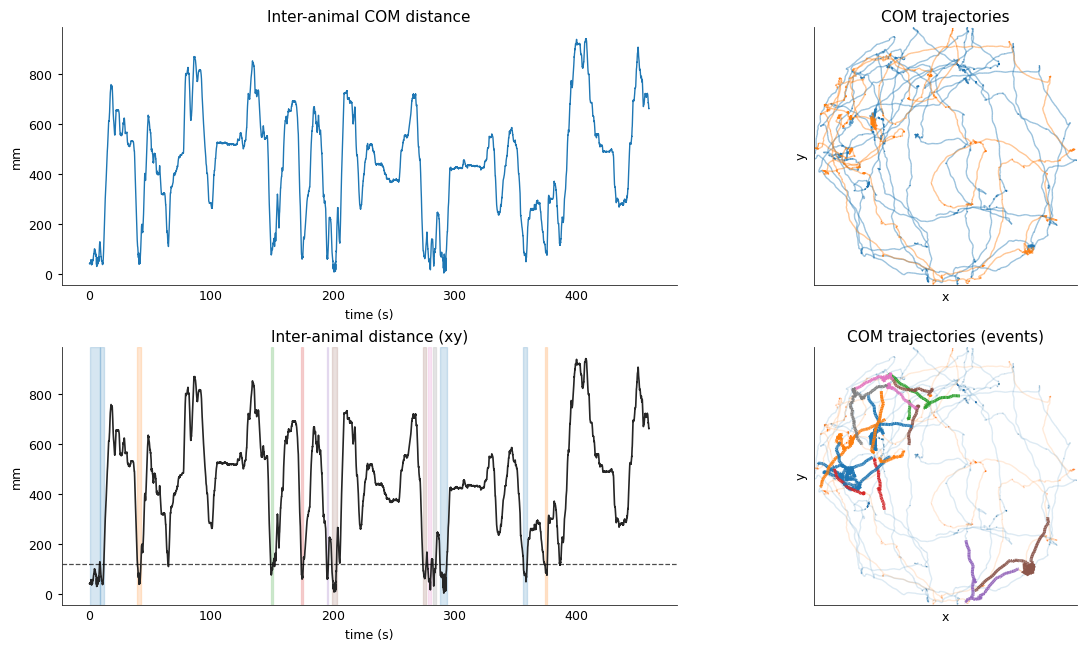

In [102]:
p = "/data/big_rim/rsync_dcc_sum/Oct3V1/2024_12_18/20240919v1l5r1mini_p20240717PMC_social_test_11_30"
plot_social_quad_poster(p, fps=30.0, dist_thresh=120.0, annotate_meetings=False, save=False, show=True)


In [ ]:
import os
import numpy as np
import scipy.io as sio
import matplotlib.pyplot as plt
from matplotlib.collections import LineCollection


def plot_heading_fields_with_overlap(
    base_path,
    pred_folder='DANNCE/predict00',
    com_dir='yolo_tracking/predict_train_lone_social_retrain_0917',
    vis_dir='COM/predict00/vis',
    pair=(0, 1),
    fps=30.0,
    px_to_mm=None,               # e.g., 0.5 to convert px→mm for axes & speed thresholds
    # arrow density / clarity
    step=10,                     # plot every Nth valid frame
    smooth_win=3,                # moving-average window (frames) for heading vectors (odd recommended)
    min_speed=None,              # mm/s (if px_to_mm provided) else “units/s”; if None → auto from data (5th pct)
    # overlap restriction to social meetings (optional)
    meeting_dist_thresh=None,    # e.g., 100.0 (same notion as your other function)
    highlight_window_s=0.75,     # extend meeting windows by ± seconds when restricting
    # arena (optional circle fit for annotations/derived metrics; not required for plotting arrows)
    arena_center=None,           # (cx, cy) if known; otherwise set fit_arena=True to estimate
    arena_radius=None,           # R if known
    fit_arena=False,             # estimate (cx, cy, R) from the outer ring of positions
    fit_percentile=95,           # percentile of radial distance used for circle fit
    # style
    animal_colors=('C0','C1'),
    titles=('Heading — Animal A','Heading — Animal B','Heading — Overlap'),
    filenames=('heading_A.png','heading_B.png','heading_overlap.png'),
    show=True,
    save=False
):
    """
    Three panels:
      (A) per-frame heading arrows for Animal A,
      (B) per-frame heading arrows for Animal B,
      (C) both overlapped (optionally limited to meeting windows).
    Headings are derived from COM velocity (direction only).
    """

    # ---------- 1) Load COM to (T,2,N) ----------
    primary = os.path.join(base_path, pred_folder, 'com3d_used.mat')
    fallback = os.path.join(base_path, com_dir, 'com3d0.mat')
    com_file = primary if os.path.isfile(primary) else fallback
    if not os.path.isfile(com_file):
        raise FileNotFoundError(f"Neither {primary} nor {fallback} exists.")
    raw = sio.loadmat(com_file).get('com')
    if raw is None:
        raise KeyError(f"'com' variable not found in {com_file}")

    if raw.ndim == 3 and raw.shape[1] == 3:
        com_xy = raw[:, :2, :]
    elif raw.ndim == 3 and raw.shape[1] == 2:
        com_xy = raw
    elif raw.ndim == 2 and raw.shape[1] % 3 == 0:
        N = raw.shape[1] // 3
        com_xy = raw.reshape(-1, 3, N)[:, :2, :]
    elif raw.ndim == 2 and raw.shape[1] % 2 == 0:
        N = raw.shape[1] // 2
        com_xy = raw.reshape(-1, 2, N)
    else:
        raise ValueError(f"Unexpected COM shape {raw.shape}")

    T, _, N = com_xy.shape
    if max(pair) >= N:
        raise ValueError(f"Pair index {pair} exceeds #animals {N}")

    x1, y1 = com_xy[:, 0, pair[0]], com_xy[:, 1, pair[0]]
    x2, y2 = com_xy[:, 0, pair[1]], com_xy[:, 1, pair[1]]
    valid = np.isfinite(x1) & np.isfinite(y1) & np.isfinite(x2) & np.isfinite(y2)

    # apply unit scaling if provided
    if px_to_mm is not None:
        scale = float(px_to_mm)
        x1, y1 = x1 * scale, y1 * scale
        x2, y2 = x2 * scale, y2 * scale
        ulabel = ' (mm)'
        speed_scale = scale
    else:
        ulabel = ''
        speed_scale = 1.0

    # ---------- 2) Heading from velocity (direction only) ----------
    # Use central differences; multiply by fps to express per second (for thresholding)
    def vel(x):
        # central diff with endpoints handled by forward/backward diff
        dx = np.empty_like(x)
        dx[1:-1] = (x[2:] - x[:-2]) * 0.5
        dx[0] = x[1] - x[0]
        dx[-1] = x[-1] - x[-2]
        return dx

    vx1 = vel(x1) * fps
    vy1 = vel(y1) * fps
    vx2 = vel(x2) * fps
    vy2 = vel(y2) * fps

    speed1 = np.hypot(vx1, vy1) * 1.0  # units/s
    speed2 = np.hypot(vx2, vy2) * 1.0

    # choose min_speed if None (robust 5th percentile of non-zero speeds)
    if min_speed is None:
        s_all = np.concatenate([speed1[valid], speed2[valid]])
        s_pos = s_all[np.isfinite(s_all) & (s_all > 0)]
        thr = np.percentile(s_pos, 5) if s_pos.size else 0.0
        min_speed = float(thr)
    else:
        min_speed = float(min_speed)

    # Unit heading vectors (mask near-stationary)
    def unitize(vx, vy, spd, thr):
        u = np.zeros((len(vx), 2), dtype=float)
        ok = np.isfinite(vx) & np.isfinite(vy) & (spd >= thr)
        mag = np.hypot(vx[ok], vy[ok])
        u[ok, 0] = vx[ok] / mag
        u[ok, 1] = vy[ok] / mag
        return u, ok

    u1, ok1 = unitize(vx1, vy1, speed1, min_speed)
    u2, ok2 = unitize(vx2, vy2, speed2, min_speed)

    # simple smoothing in Cartesian (then renormalize)
    def smooth_unit(U, ok, win=3):
        if win is None or win <= 1:
            return U
        k = int(win)
        k = k + 1 if (k % 2 == 0) else k
        pad = k // 2
        # pad with zeros; only meaningful where ok
        Ux = np.convolve(U[:,0], np.ones(k)/k, mode='same')
        Uy = np.convolve(U[:,1], np.ones(k)/k, mode='same')
        Us = np.stack([Ux, Uy], axis=1)
        # renormalize where we originally had a vector
        mag = np.hypot(Us[:,0], Us[:,1])
        nz = (mag > 0) & ok
        Us[nz,0] /= mag[nz]
        Us[nz,1] /= mag[nz]
        # where not ok, keep zeros
        Us[~ok] = 0.0
        return Us

    u1 = smooth_unit(u1, ok1, smooth_win)
    u2 = smooth_unit(u2, ok2, smooth_win)

    # ---------- 3) Meeting mask (optional restriction for overlap) ----------
    meeting_mask = np.ones(T, dtype=bool)
    if meeting_dist_thresh is not None:
        d = np.full(T, np.nan)
        d[valid] = np.hypot(x1[valid] - x2[valid], y1[valid] - y2[valid])
        m = np.isfinite(d) & (d <= float(meeting_dist_thresh))
        # expand by ±window
        pad = int(round(highlight_window_s * fps))
        mm = np.zeros_like(m, dtype=bool)
        idx = np.flatnonzero(m)
        for i in idx:
            s = max(0, i - pad)
            e = min(T-1, i + pad)
            mm[s:e+1] = True
        meeting_mask = mm

    # ---------- 4) Circle fit (optional; not strictly needed for arrows) ----------
    cx, cy, R = None, None, None
    if arena_center is not None and arena_radius is not None:
        cx, cy = float(arena_center[0]), float(arena_center[1])
        R = float(arena_radius)
    elif fit_arena:
        # use both animals' valid positions
        X = np.concatenate([x1[valid], x2[valid]])
        Y = np.concatenate([y1[valid], y2[valid]])
        # initial center guess as mean
        x0, y0 = np.mean(X), np.mean(Y)
        # select outer ring points
        r = np.hypot(X - x0, Y - y0)
        thr = np.percentile(r, fit_percentile)
        sel = r >= thr
        Xo, Yo = X[sel], Y[sel]
        if Xo.size >= 3:
            # Kåsa algebraic circle fit: solve A*params=b where params=[a,b,c], center=(a,b), R=sqrt(a^2+b^2+c)
            A = np.column_stack([2*Xo, 2*Yo, np.ones_like(Xo)])
            bvec = Xo*Xo + Yo*Yo
            try:
                params, *_ = np.linalg.lstsq(A, bvec, rcond=None)
                a, b, c = params
                cx, cy = float(a), float(b)
                R = float(np.sqrt(a*a + b*b + c))
            except np.linalg.LinAlgError:
                cx, cy, R = None, None, None

    # ---------- 5) Common extents ----------
    xmin = np.nanmin([np.nanmin(x1), np.nanmin(x2)])
    xmax = np.nanmax([np.nanmax(x1), np.nanmax(x2)])
    ymin = np.nanmin([np.nanmin(y1), np.nanmin(y2)])
    ymax = np.nanmax([np.nanmax(y1), np.nanmax(y2)])
    extent = (xmin, xmax, ymin, ymax)

    # helper to draw arena ring
    def draw_ring(ax):
        if cx is not None and R is not None:
            th = np.linspace(0, 2*np.pi, 361)
            ax.plot(cx + R*np.cos(th), cy + R*np.sin(th), color='0.7', lw=1.0, alpha=0.8)

    # helper to plot one animal panel
    def plot_panel(x, y, U, ok, color, title, restrict_mask=None):
        fig, ax = plt.subplots(figsize=(6.0, 6.0))
        ax.set_aspect('equal', 'box')
        # choose indices to draw
        idx = np.flatnonzero(ok)
        if restrict_mask is not None:
            idx = idx[restrict_mask[idx]]
        idx = idx[::max(1,int(step))]
        # quiver: fixed arrow length (direction only)
        q = ax.quiver(x[idx], y[idx], U[idx,0], U[idx,1],
                      angles='xy', scale_units='xy', scale=1.0, width=0.003,
                      color=color, alpha=0.9)
        draw_ring(ax)
        ax.set_xlim(extent[0], extent[1]); ax.set_ylim(extent[2], extent[3])
        ax.set_title(f"{title} — {os.path.basename(base_path)}")
        ax.set_xlabel('x' + ulabel); ax.set_ylabel('y' + ulabel)
        return fig, ax

    # ---------- 6) Panels ----------
    figA, axA = plot_panel(x1, y1, u1, ok1 & valid, animal_colors[0], titles[0], None)
    figB, axB = plot_panel(x2, y2, u2, ok2 & valid, animal_colors[1], titles[1], None)

    # overlap: optionally restrict to meeting windows
    restrict = meeting_mask if meeting_dist_thresh is not None else np.ones(T, dtype=bool)
    figC, axC = plt.subplots(figsize=(6.6, 6.6))
    axC.set_aspect('equal', 'box')
    draw_ring(axC)

    idx1 = np.flatnonzero(ok1 & valid & restrict)[::max(1,int(step))]
    idx2 = np.flatnonzero(ok2 & valid & restrict)[::max(1,int(step))]

    axC.quiver(x1[idx1], y1[idx1], u1[idx1,0], u1[idx1,1],
               angles='xy', scale_units='xy', scale=1.0, width=0.003,
               color=animal_colors[0], alpha=0.85)
    axC.quiver(x2[idx2], y2[idx2], u2[idx2,0], u2[idx2,1],
               angles='xy', scale_units='xy', scale=1.0, width=0.003,
               color=animal_colors[1], alpha=0.85)

    axC.set_xlim(extent[0], extent[1]); axC.set_ylim(extent[2], extent[3])
    axC.set_title(titles[2] + (' (meetings only)' if meeting_dist_thresh is not None else '') +
                  f' — {os.path.basename(base_path)}')
    axC.set_xlabel('x' + ulabel); axC.set_ylabel('y' + ulabel)

    # ---------- 7) Save / show ----------
    if save:
        out_dir = os.path.join(base_path, vis_dir)
        os.makedirs(out_dir, exist_ok=True)
        figA.tight_layout(); figB.tight_layout(); figC.tight_layout()
        figA.savefig(os.path.join(out_dir, filenames[0]), dpi=300)
        figB.savefig(os.path.join(out_dir, filenames[1]), dpi=300)
        figC.savefig(os.path.join(out_dir, filenames[2]), dpi=300)

    if not show:
        plt.close(figA); plt.close(figB); plt.close(figC)

    return dict(
        headings_A=u1, mask_A=(ok1 & valid),
        headings_B=u2, mask_B=(ok2 & valid),
        center=(cx, cy), radius=R, extent=extent
    )


In [82]:
import os
import numpy as np
import scipy.io as sio
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap, to_rgb

# =========================
# --- Common utilities  ---
# =========================

def _load_com_xy(base_path, pred_folder, com_dir):
    primary = os.path.join(base_path, pred_folder, 'com3d_used.mat')
    fallback = os.path.join(base_path, com_dir, 'com3d0.mat')
    com_file = primary if os.path.isfile(primary) else fallback
    if not os.path.isfile(com_file):
        raise FileNotFoundError(f"Neither {primary} nor {fallback} exists.")
    raw = sio.loadmat(com_file).get('com')
    if raw is None:
        raise KeyError(f"'com' variable not found in {com_file}")
    if raw.ndim == 3 and raw.shape[1] == 3:
        com_xy = raw[:, :2, :]
    elif raw.ndim == 3 and raw.shape[1] == 2:
        com_xy = raw
    elif raw.ndim == 2 and raw.shape[1] % 3 == 0:
        N = raw.shape[1] // 3
        com_xy = raw.reshape(-1, 3, N)[:, :2, :]
    elif raw.ndim == 2 and raw.shape[1] % 2 == 0:
        N = raw.shape[1] // 2
        com_xy = raw.reshape(-1, 2, N)
    else:
        raise ValueError(f"Unexpected COM shape {raw.shape}")
    return com_xy

def _central_diff(x):
    dx = np.empty_like(x)
    dx[1:-1] = (x[2:] - x[:-2]) * 0.5
    dx[0] = x[1] - x[0]
    dx[-1] = x[-1] - x[-2]
    return dx

def _wrap_to_pi(a):
    return (a + np.pi) % (2*np.pi) - np.pi

def _white_to_color_cmap(color, name='w2c'):
    rgb = to_rgb(color)
    return LinearSegmentedColormap.from_list(name, [(1,1,1,0.0), (*rgb,1.0)])

def _fit_arena_circle(X, Y, percentile=95):
    # Kåsa algebraic fit on outer ring points
    x0, y0 = np.mean(X), np.mean(Y)
    r = np.hypot(X - x0, Y - y0)
    thr = np.percentile(r, percentile)
    sel = r >= thr
    if np.count_nonzero(sel) < 3:
        return None, None, None
    Xo, Yo = X[sel], Y[sel]
    A = np.column_stack([2*Xo, 2*Yo, np.ones_like(Xo)])
    b = Xo*Xo + Yo*Yo
    try:
        params, *_ = np.linalg.lstsq(A, b, rcond=None)
        a, c, d = params
        cx, cy = float(a), float(c)
        R = float(np.sqrt(a*a + c*c + d))
        return cx, cy, R
    except np.linalg.LinAlgError:
        return None, None, None

def _compute_heading_theta(x, y, fps, px_to_mm=None, min_speed=None, smooth_win=3):
    # Optionally scale units for speed thresholds
    if px_to_mm is not None:
        s = float(px_to_mm)
        x = x * s; y = y * s

    vx = _central_diff(x) * fps
    vy = _central_diff(y) * fps
    speed = np.hypot(vx, vy)

    if min_speed is None:
        sp = speed[np.isfinite(speed) & (speed > 0)]
        thr = np.percentile(sp, 5) if sp.size else 0.0
        min_speed = float(thr)
    else:
        min_speed = float(min_speed)

    # heading only where moving
    ok = np.isfinite(vx) & np.isfinite(vy) & (speed >= min_speed)
    # simple smoothing of components (moving average)
    def _smooth(arr, k):
        if k is None or k <= 1: return arr
        k = int(k);  k = k + 1 if (k % 2 == 0) else k
        return np.convolve(arr, np.ones(k)/k, mode='same')
    vx_s = _smooth(vx, smooth_win)
    vy_s = _smooth(vy, smooth_win)

    theta = np.full_like(vx_s, np.nan, dtype=float)
    theta[ok] = np.arctan2(vy_s[ok], vx_s[ok])
    return theta, ok  # radians, mask

def _meeting_mask(x1, y1, x2, y2, dist_thresh, fps, pad_s=0.75):
    d = np.full_like(x1, np.nan, dtype=float)
    v = np.isfinite(x1) & np.isfinite(y1) & np.isfinite(x2) & np.isfinite(y2)
    d[v] = np.hypot(x1[v] - x2[v], y1[v] - y2[v])
    meet = np.isfinite(d) & (d <= float(dist_thresh))
    if not np.any(meet):
        return np.zeros_like(meet, dtype=bool)
    pad = int(round(pad_s * fps))
    mm = np.zeros_like(meet, dtype=bool)
    idx = np.flatnonzero(meet)
    # cheap dilation by a fixed window
    for i in idx:
        s = max(0, i - pad); e = min(len(meet)-1, i + pad)
        mm[s:e+1] = True
    return mm

# ======================================================
# 1) Dual rose plot (A vs B) with meeting overlay
# ======================================================

def plot_heading_rose_dual(
    base_path,
    pred_folder='DANNCE/predict00',
    com_dir='yolo_tracking/predict_train_lone_social_retrain_0917',
    pair=(0,1),
    fps=30.0,
    px_to_mm=None,
    min_speed=None,
    smooth_win=3,
    nbins=36,
    dist_thresh_for_meetings=None,  # if set, overlay meeting subset
    meeting_window_s=0.75,
    animal_colors=('C0','C1'),
    show=True, save=False, vis_dir='COM/predict00/vis', filename='rose_dual.png'
):
    com = _load_com_xy(base_path, pred_folder, com_dir)
    x1, y1 = com[:,0,pair[0]], com[:,1,pair[0]]
    x2, y2 = com[:,0,pair[1]], com[:,1,pair[1]]

    theta1, ok1 = _compute_heading_theta(x1, y1, fps, px_to_mm, min_speed, smooth_win)
    theta2, ok2 = _compute_heading_theta(x2, y2, fps, px_to_mm, min_speed, smooth_win)

    meet_mask = None
    if dist_thresh_for_meetings is not None:
        meet_mask = _meeting_mask(x1, y1, x2, y2, dist_thresh_for_meetings, fps, meeting_window_s)

    # bins
    edges = np.linspace(0, 2*np.pi, nbins+1)
    centers = (edges[:-1] + edges[1:]) / 2
    w = edges[1] - edges[0]

    def _hist(theta, mask):
        th = theta[mask]
        th = th[~np.isnan(th)]
        if th.size == 0:
            return np.zeros(nbins)
        H, _ = np.histogram(np.mod(th, 2*np.pi), bins=edges)
        return H.astype(float)

    H1_all = _hist(theta1, ok1)
    H2_all = _hist(theta2, ok2)
    H1_m = _hist(theta1, ok1 & meet_mask) if meet_mask is not None else None
    H2_m = _hist(theta2, ok2 & meet_mask) if meet_mask is not None else None

    # circular means / vector strengths
    def _circ_stats(theta, mask):
        th = theta[mask]
        th = th[~np.isnan(th)]
        if th.size == 0: return 0.0, 0.0
        C = np.mean(np.cos(th)); S = np.mean(np.sin(th))
        mu = np.arctan2(S, C)
        R = np.hypot(C, S)
        return mu, R

    mu1, R1 = _circ_stats(theta1, ok1)
    mu2, R2 = _circ_stats(theta2, ok2)

    # plot
    fig, axs = plt.subplots(1, 2, subplot_kw={'projection': 'polar'}, figsize=(10,5))
    for ax, H_all, H_meet, color, (mu, R), title in [
        (axs[0], H1_all, H1_m, animal_colors[0], (mu1, R1), 'Animal A'),
        (axs[1], H2_all, H2_m, animal_colors[1], (mu2, R2), 'Animal B'),
    ]:
        maxH = max(1.0, H_all.max() if H_all.size else 1.0)
        ax.bar(centers, H_all, width=w, color=color, alpha=0.35, edgecolor='none', align='center')
        if H_meet is not None:
            ax.bar(centers, H_meet, width=w, color=color, alpha=0.9, edgecolor='none', align='center')
        # mean vector
        ax.plot([0, mu], [0, R*maxH], color='k', lw=2, alpha=0.9)
        ax.set_title(f'{title}\nR={R:.2f}', va='bottom')
        ax.set_theta_zero_location('E'); ax.set_theta_direction(-1)  # 0° = +x, CW

    fig.suptitle(os.path.basename(base_path))
    fig.tight_layout()

    if save:
        out_dir = os.path.join(base_path, vis_dir); os.makedirs(out_dir, exist_ok=True)
        fig.savefig(os.path.join(out_dir, filename), dpi=300)
    if not show:
        plt.close(fig)
    return dict(theta1=theta1, ok1=ok1, theta2=theta2, ok2=ok2, centers=centers, edges=edges)

# ======================================================
# 2) Dual perimeter ring map (cosψ around the wall)
# ======================================================

def plot_perimeter_ring_map_dual(
    base_path,
    pred_folder='DANNCE/predict00',
    com_dir='yolo_tracking/predict_train_lone_social_retrain_0917',
    pair=(0,1),
    fps=30.0,
    px_to_mm=None,
    min_speed=None,
    smooth_win=3,
    bins_theta=36,
    fit_arena=True,
    arena_center=None, arena_radius=None, fit_percentile=95,
    ring_cmap='coolwarm',
    ring_lw=10.0,     # thickness of the colored ring
    radial_clip=0.7,  # ignore frames too close to center (fraction of R) to emphasize wall behavior
    show=True, save=False, vis_dir='COM/predict00/vis', filename='ring_dual.png',
    animal_labels=('Animal A','Animal B')
):
    com = _load_com_xy(base_path, pred_folder, com_dir)
    x1, y1 = com[:,0,pair[0]], com[:,1,pair[0]]
    x2, y2 = com[:,0,pair[1]], com[:,1,pair[1]]

    if px_to_mm is not None:
        s = float(px_to_mm)
        x1, y1 = x1*s, y1*s
        x2, y2 = x2*s, y2*s

    # arena center & radius
    if arena_center is not None and arena_radius is not None:
        cx, cy = float(arena_center[0]), float(arena_center[1])
        R = float(arena_radius)
    elif fit_arena:
        X = np.concatenate([x1[np.isfinite(x1)], x2[np.isfinite(x2)]])
        Y = np.concatenate([y1[np.isfinite(y1)], y2[np.isfinite(y2)]])
        cx, cy, R = _fit_arena_circle(X, Y, percentile=fit_percentile)
    else:
        cx = cy = R = None

    # headings
    t1, ok1 = _compute_heading_theta(x1, y1, fps, None, min_speed, smooth_win)
    t2, ok2 = _compute_heading_theta(x2, y2, fps, None, min_speed, smooth_win)

    # compute cosψ per frame (ψ = angle between heading and inward radial)
    def _cospsi(x, y, theta, ok):
        v = np.isfinite(x) & np.isfinite(y) & ok
        if not np.any(v) or cx is None or R is None:
            return np.array([]), np.array([])
        rx, ry = x[v] - cx, y[v] - cy
        norm = np.hypot(rx, ry)
        nz = norm > 0
        rx, ry = rx[nz]/norm[nz], ry[nz]/norm[nz]  # unit outward radial
        # inward radial = - (rx, ry)
        hx, hy = np.cos(theta[v][nz]), np.sin(theta[v][nz])
        cospsi = -(hx*rx + hy*ry)  # +1 facing center; -1 facing wall
        angle_pos = np.arctan2(y[v][nz] - cy, x[v][nz] - cx)  # arena angle where the animal is
        rfrac = (np.hypot(x[v][nz] - cy, y[v][nz] - cy) if False else np.hypot((x[v][nz]-cx),(y[v][nz]-cy))) / R
        keep = rfrac >= radial_clip
        return angle_pos[keep], cospsi[keep]

    th1, c1 = _cospsi(x1, y1, t1, ok1)
    th2, c2 = _cospsi(x2, y2, t2, ok2)

    # bin means by arena angle
    edges = np.linspace(-np.pi, np.pi, bins_theta+1)
    def _bin_mean(th, val):
        if th.size == 0: return np.zeros(bins_theta), np.zeros(bins_theta, dtype=int)
        idx = np.digitize(_wrap_to_pi(th), edges) - 1
        idx = np.clip(idx, 0, bins_theta-1)
        sums = np.bincount(idx, weights=val, minlength=bins_theta)
        cnts = np.bincount(idx, minlength=bins_theta)
        m = np.zeros_like(sums); nz = cnts > 0; m[nz] = sums[nz] / cnts[nz]
        return m, cnts

    m1, n1 = _bin_mean(th1, c1)
    m2, n2 = _bin_mean(th2, c2)
    centers = (edges[:-1] + edges[1:]) / 2

    # plot as colored arcs on a circle (two subplots)
    fig, axs = plt.subplots(1, 2, figsize=(10,5))
    for ax, m, cnt, label in [(axs[0], m1, n1, animal_labels[0]), (axs[1], m2, n2, animal_labels[1])]:
        ax.set_aspect('equal', 'box')
        ax.axis('off')
        if cx is None or R is None:
            # fallback: use unified radius from data
            X = np.concatenate([x1[np.isfinite(x1)], x2[np.isfinite(x2)]])
            Y = np.concatenate([y1[np.isfinite(y1)], y2[np.isfinite(y2)]])
            cx_ = np.mean(X); cy_ = np.mean(Y); R_ = 0.5*(np.max(np.hypot(X-cx_, Y-cy_))+np.min(np.hypot(X-cx_, Y-cy_)))
        else:
            cx_, cy_, R_ = cx, cy, R

        # ring radius to draw (relative coords for display only)
        rr = 1.0
        # draw base circle
        th = np.linspace(0, 2*np.pi, 361)
        ax.plot(rr*np.cos(th), rr*np.sin(th), color='0.7', lw=1.0)
        # colored arcs (loop over ~36 bins is fine for plotting)
        norm = plt.Normalize(-1, 1)
        cmap = plt.get_cmap(ring_cmap)
        for k in range(len(centers)):
            if cnt[k] == 0:  # skip empty bins
                continue
            th0 = centers[k] - (edges[1]-edges[0])/2
            th1_ = centers[k] + (edges[1]-edges[0])/2
            seg = np.linspace(th0, th1_, 25)
            ax.plot(rr*np.cos(seg), rr*np.sin(seg),
                    color=cmap(norm(m[k])), lw=ring_lw, solid_capstyle='butt')
        ax.set_title(f'{label}\n⟨cosψ⟩ around perimeter\n(+1 center, −1 wall)', fontsize=10)

    fig.suptitle(os.path.basename(base_path))
    fig.tight_layout()

    if save:
        out_dir = os.path.join(base_path, vis_dir); os.makedirs(out_dir, exist_ok=True)
        fig.savefig(os.path.join(out_dir, filename), dpi=300)
    if not show:
        plt.close(fig)
    return dict(theta_bins=centers, mean_cospsi_A=m1, n_A=n1, mean_cospsi_B=m2, n_B=n2)

# ======================================================
# 3) Spatial social-orientation hexbin overlay
#    Metric: P(|δ| ≤ theta0) (prob. looking toward partner)
# ======================================================

def plot_social_orientation_hexbin_overlay(
    base_path,
    pred_folder='DANNCE/predict00',
    com_dir='yolo_tracking/predict_train_lone_social_retrain_0917',
    pair=(0,1),
    fps=30.0,
    px_to_mm=None,
    min_speed=None,
    smooth_win=3,
    dist_thresh_for_meetings=100.0,  # restrict to meetings ±window
    meeting_window_s=0.75,
    theta0_deg=30.0,          # "toward partner" half-angle
    gridsize=60,
    mincnt=10,                # hide sparse bins
    animal_colors=('C0','C1'),
    show=True, save=False, vis_dir='COM/predict00/vis', filename='social_hexbin_overlay.png'
):
    com = _load_com_xy(base_path, pred_folder, com_dir)
    x1, y1 = com[:,0,pair[0]], com[:,1,pair[0]]
    x2, y2 = com[:,0,pair[1]], com[:,1,pair[1]]

    if px_to_mm is not None:
        s = float(px_to_mm)
        x1, y1 = x1*s, y1*s
        x2, y2 = x2*s, y2*s
        ulabel = ' (mm)'
    else:
        ulabel = ''

    t1, ok1 = _compute_heading_theta(x1, y1, fps, None, min_speed, smooth_win)
    t2, ok2 = _compute_heading_theta(x2, y2, fps, None, min_speed, smooth_win)

    valid = np.isfinite(x1) & np.isfinite(y1) & np.isfinite(x2) & np.isfinite(y2)

    # meeting restriction
    restrict = _meeting_mask(x1, y1, x2, y2, dist_thresh_for_meetings, fps, meeting_window_s)
    M = valid & restrict

    # bearing to partner
    phi12 = np.full_like(t1, np.nan);  phi21 = np.full_like(t2, np.nan)
    v12 = np.isfinite(x1) & np.isfinite(y1) & np.isfinite(x2) & np.isfinite(y2)
    phi12[v12] = np.arctan2(y2[v12] - y1[v12], x2[v12] - x1[v12])  # partner seen from 1
    phi21[v12] = np.arctan2(y1[v12] - y2[v12], x1[v12] - x2[v12])  # partner seen from 2

    # delta angles
    d1 = _wrap_to_pi(t1 - phi12)
    d2 = _wrap_to_pi(t2 - phi21)

    th0 = np.deg2rad(theta0_deg)
    ind1 = (np.abs(d1) <= th0)
    ind2 = (np.abs(d2) <= th0)

    # Build figure
    fig, ax = plt.subplots(figsize=(6.8, 6.2))
    ax.set_aspect('equal', 'box')

    # Layer A
    cmapA = _white_to_color_cmap(animal_colors[0], 'Ahex')
    hb1 = ax.hexbin(
        x1[M & np.isfinite(d1)], y1[M & np.isfinite(d1)],
        C=ind1[M & np.isfinite(d1)].astype(float),
        reduce_C_function=np.mean, gridsize=gridsize, mincnt=mincnt,
        cmap=cmapA, vmin=0.0, vmax=1.0, linewidths=0.0, alpha=0.70
    )
    # Layer B
    cmapB = _white_to_color_cmap(animal_colors[1], 'Bhex')
    hb2 = ax.hexbin(
        x2[M & np.isfinite(d2)], y2[M & np.isfinite(d2)],
        C=ind2[M & np.isfinite(d2)].astype(float),
        reduce_C_function=np.mean, gridsize=gridsize, mincnt=mincnt,
        cmap=cmapB, vmin=0.0, vmax=1.0, linewidths=0.0, alpha=0.70
    )

    # colorbars (small)
    cbar1 = fig.colorbar(hb1, ax=ax, fraction=0.035, pad=0.02)
    cbar1.set_label('P(toward partner) — A')
    cbar2 = fig.colorbar(hb2, ax=ax, fraction=0.035, pad=0.12)
    cbar2.set_label('P(toward partner) — B')

    ax.set_title(f"Social orientation map (|δ| ≤ {theta0_deg:.0f}°)\n{os.path.basename(base_path)}")
    ax.set_xlabel('x' + ulabel); ax.set_ylabel('y' + ulabel)

    if save:
        out_dir = os.path.join(base_path, vis_dir); os.makedirs(out_dir, exist_ok=True)
        fig.tight_layout()
        fig.savefig(os.path.join(out_dir, filename), dpi=300)
    if not show:
        plt.close(fig)

    return dict(theta0=theta0_deg, gridsize=gridsize, mincnt=mincnt)


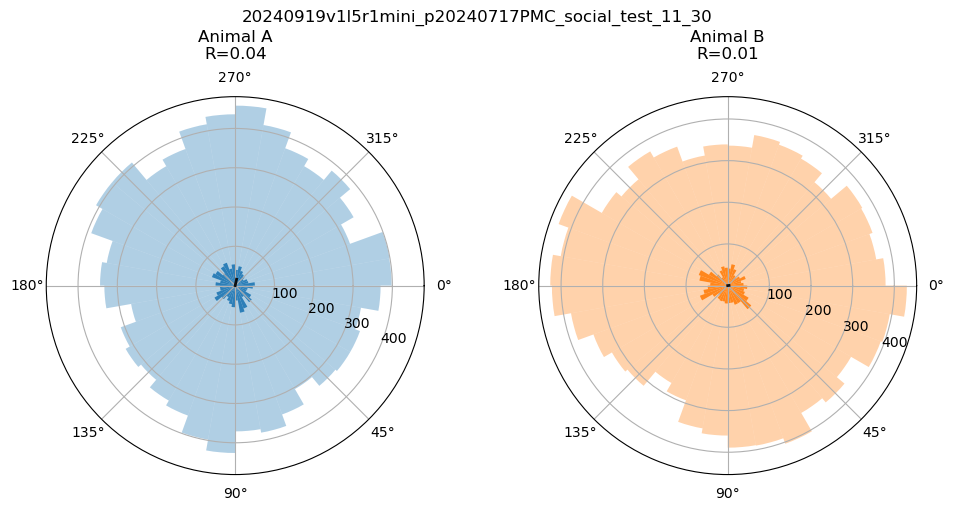

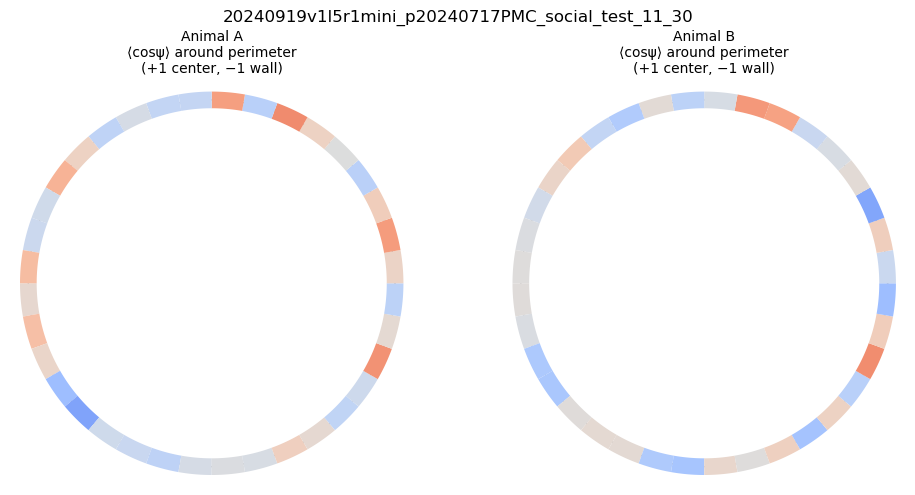

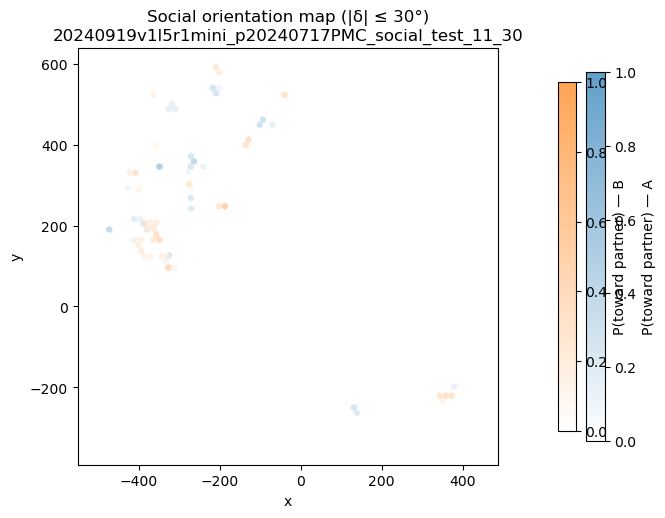

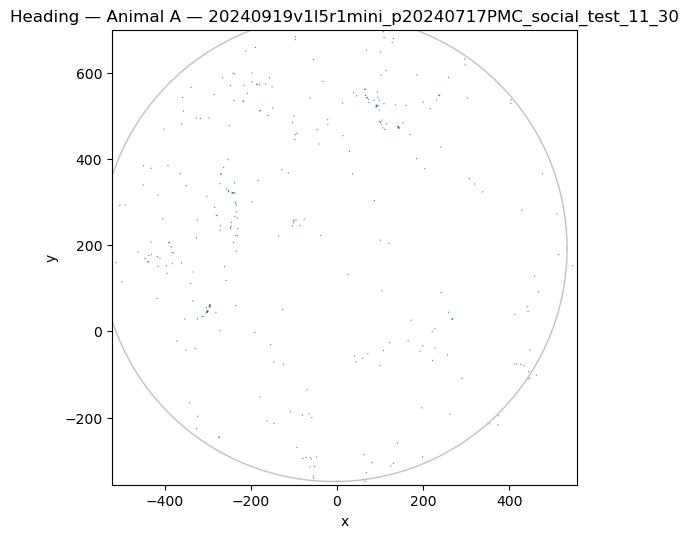

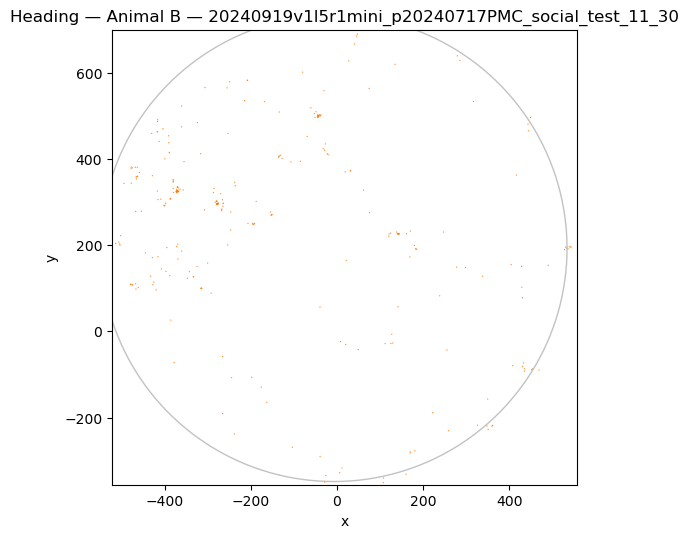

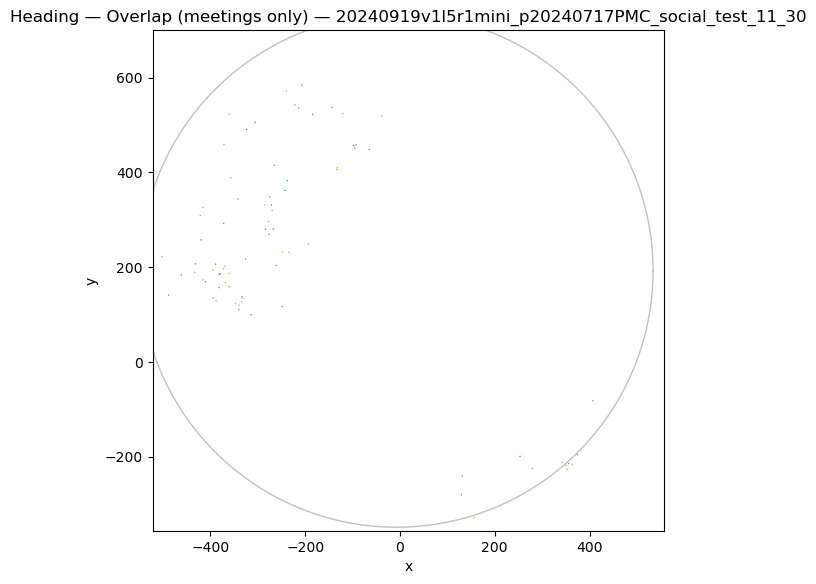

In [ ]:
out = plot_heading_fields_with_overlap(
    base_path=p,
    fps=30.0,
    px_to_mm=None,              # set your px→mm here if you want mm axes & speed in mm/s
    step=12,                    # sparser arrows
    smooth_win=5,               # slightly smoother headings
    min_speed=None,             # let it auto-pick from data
    meeting_dist_thresh=100.0,  # restrict overlap panel to meetings ± window
    highlight_window_s=0.75,
    fit_arena=True,             # estimate center/radius from outer ring
    animal_colors=('C0','C1'),
    save=False, show=True
)
